## Import libraries

In [37]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [38]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [39]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers
from tabulate import tabulate
from pydantic import BaseModel
from typing import Dict, List
import joblib
import json
import time
import os

MODEL_DIR  = "models"
MODELS_JSON = "models.json"
CICEVSE_SUBDIR = f"{MODEL_DIR}/cicevse"
CICIDS_SUBDIR  = f"{MODEL_DIR}/cicids"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CICEVSE_SUBDIR, exist_ok=True)
os.makedirs(CICIDS_SUBDIR, exist_ok=True)

def _load_registry() -> dict:
    if os.path.exists(MODELS_JSON):
        with open(MODELS_JSON) as f:
            return json.load(f)
    return {}

def _save_registry(registry: dict):
    with open(MODELS_JSON, "w") as f:
        json.dump(registry, f, indent=2)

In [40]:
import shutil

def _migrate_models_to_subdirs():
    """One-time migration: move flat models/* files into models/cicevse/ and update registry."""
    registry = _load_registry()
    if not registry:
        return

    needs_migration = any(
        not entry.get("model_path", "").startswith(f"{CICEVSE_SUBDIR}/")
        for entry in registry.values()
    )
    if not needs_migration:
        return

    new_registry = {}
    for old_key, entry in registry.items():
        old_path = entry["model_path"]
        filename = os.path.basename(old_path)
        new_path = f"{CICEVSE_SUBDIR}/{filename}"

        if os.path.exists(old_path) and not os.path.exists(new_path):
            shutil.move(old_path, new_path)
        elif os.path.exists(old_path) and os.path.exists(new_path):
            os.remove(old_path)

        new_key = f"[CICEVSE] {old_key}" if not old_key.startswith("[") else old_key

        new_entry = dict(entry)
        new_entry["model_path"] = new_path
        new_entry["dataset"] = "cicevse"
        new_registry[new_key] = new_entry

    _save_registry(new_registry)
    print(f"Migrated {len(new_registry)} model(s) to {CICEVSE_SUBDIR}/")

_migrate_models_to_subdirs()

In [41]:
# Configure TensorFlow to use GPU > TPU > CPU (whichever is available)

def configure_tf_device():
    # Suppress verbose TF/CUDA logs before device selection
    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

    # 1. Try TPU
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f"TPU detected — using TPUStrategy ({strategy.num_replicas_in_sync} cores)")
        return strategy, "TPU"
    except (ValueError, tf.errors.NotFoundError):
        pass

    # 2. Try GPU
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            strategy = tf.distribute.MirroredStrategy()
            print(f"GPU detected — using MirroredStrategy ({len(gpus)} GPU(s): "
                  f"{[g.name for g in gpus]})")
            return strategy, "GPU"
        except RuntimeError as e:
            print(f"GPU found but could not be configured: {e}")

    # 3. Fallback to CPU
    strategy = tf.distribute.get_strategy()   # default (no-op) strategy
    print("No GPU/TPU found — falling back to CPU")
    return strategy, "CPU"

tf_strategy, tf_device = configure_tf_device()


No GPU/TPU found — falling back to CPU


In [42]:
class ModelResult(BaseModel):
    model_name: str
    training_time_s: float
    inference_time_ms: float       # per-sample inference latency
    accuracy: float
    precision: float               # weighted
    recall: float                  # weighted
    f1_score: float                # weighted
    accuracy_std: float = 0.0
    precision_std: float = 0.0
    recall_std: float = 0.0
    f1_score_std: float = 0.0
    confusion_matrix: List[List[int]]
    per_class_metrics: Dict[str, Dict[str, float]]  # class label -> {precision, recall, f1-score, support}

    def to_summary_dict(self) -> dict:
        """Flat dict suitable for a summary comparison table row."""
        return {
            'Model':                   self.model_name,
            'Accuracy (%)':            f"{self.accuracy*100:.3f} ± {self.accuracy_std*100:.3f}",
            'Precision (%)':           f"{self.precision*100:.3f} ± {self.precision_std*100:.3f}",
            'Recall (%)':              f"{self.recall*100:.3f} ± {self.recall_std*100:.3f}",
            'F1-Score (%)':            f"{self.f1_score*100:.3f} ± {self.f1_score_std*100:.3f}",
            'Train Time (s)':          round(self.training_time_s,  3),
            'Infer. Time (ms/sample)': round(self.inference_time_ms, 4),
        }

### Load CICEVSE2024 data

In [43]:
# Read the dataset
df_cicevse_2024 = pd.read_csv('CICEVSE2024/Subsets/CICEVSE2024_12classes_kmeans_rule_sampled1000.csv')

In [44]:
df_cicevse_2024

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,0.0,0.396825,0.500000,0.714286,0.135668,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
1,0.0,0.476190,0.500000,0.714286,0.347005,0.453333,0.176471,0.111111,0.001221,0.020408,...,0.230769,1.000000,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
2,0.0,0.317460,0.833333,0.857143,0.703655,0.346667,0.705882,0.777778,0.008286,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1
3,0.0,0.539683,0.500000,0.714286,0.942000,0.400000,0.705882,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,10
4,0.0,0.396825,0.500000,0.714286,0.152590,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,0.0,0.396825,0.500000,0.714286,0.660441,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
35937,0.0,0.539683,0.500000,0.714286,0.929381,0.400000,0.764706,0.777778,0.145495,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,2
35938,0.0,0.317460,0.833333,0.857143,0.690272,0.346667,0.705882,0.777778,0.045853,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,3
35939,0.0,0.539683,0.500000,0.714286,0.799344,0.400000,0.705882,0.777778,0.084077,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1


In [45]:
# print the class distribution of the last column
df_cicevse_2024['Label'].value_counts()

Label
7     7696
3     5807
1     4739
8     3690
2     3421
5     3110
11    2787
10    1898
9     1577
6     1044
4       90
0       82
Name: count, dtype: int64

| Name                                                   | Original Number of Samples | Reduced Subset | Label |
|--------------------------------------------------------|----------------------------|----------------|-------|
| Class 2 DoS: TCP floods                                | 721044                     | 7696           | 7     |
| Class 1 Discovery: Stealth SYN scanning                | 530946                     | 5807           | 3     |
| Class 1 Discovery: Port scanning                       | 426659                     | 4739           | 1     |
| Class 1 Discovery: Service detection                   | 292856                     | 3690           | 8     |
| Class 2 DoS: Identity rotation and rotation flood      | 262185                     | 3421           | 2    |
| Class 3 Reconnaissance: Vulnerability scan             | 231367                     | 3110           | 5     |
| Class 3 Reconnaissance: OS fingerprinting              | 140273                     | 2787           | 11    |
| Class 3 Reconnaissance: Aggressive scan                | 102522                     | 1898           | 10    |
| Class 2 DoS: UDP flood                                 | 32475                      | 1577           | 9     |
| Class 2 DoS: Slow request starvation                   | 4201                       | 1044           | 6     |
| Class 2 DoS: ICMP flood or fragmentation               | 90                         | 90             | 4     |
| Class 0 Normal                                         | 82                         | 82             | 0     |

C:\Users\100987869\AppData\Local\Temp\ipykernel_15968\3854627974.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right')


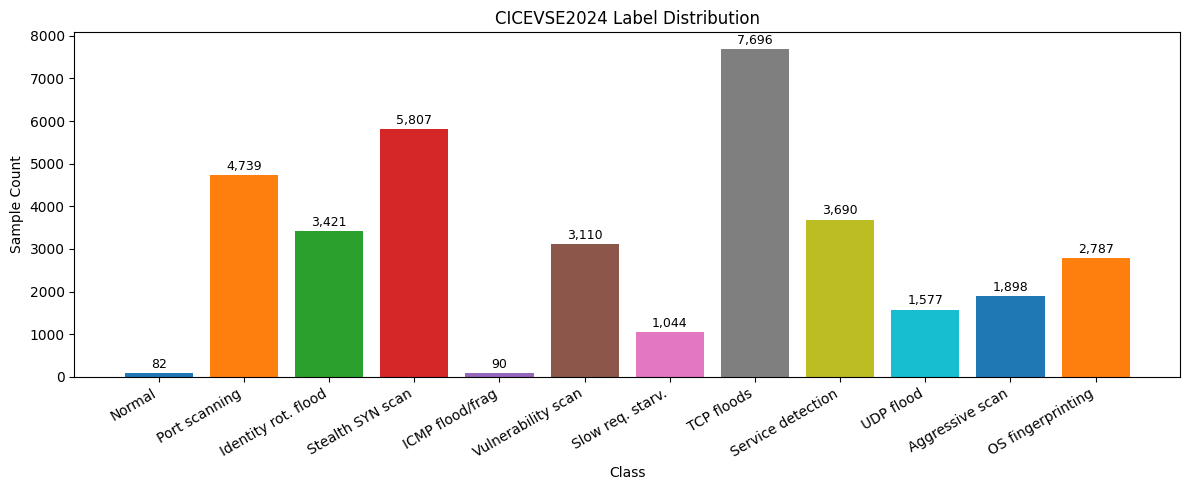

In [46]:
# Bar plot of label value counts with class names
label_names_cicevse = {
    0: 'Normal',
    1: 'Port scanning',
    2: 'Identity rot. flood',
    3: 'Stealth SYN scan',
    4: 'ICMP flood/frag',
    5: 'Vulnerability scan',
    6: 'Slow req. starv.',
    7: 'TCP floods',
    8: 'Service detection',
    9: 'UDP flood',
    10: 'Aggressive scan',
    11: 'OS fingerprinting',
}

counts = df_cicevse_2024['Label'].value_counts().sort_index()
labels = [label_names_cicevse[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('CICEVSE2024 Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Load CICIDS2017 data

In [47]:
# Read the CICIDS2017 dataset
df_cicids_2017 = pd.read_csv(r'c:\Users\100987869\Downloads\cic_0.01km.csv')

In [48]:
df_cicids_2017

,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow IAT Mean,Flow IAT Min,Fwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,URG Flag Count,Down/Up Ratio,Init_Win_bytes_forward,Init_Win_bytes_backward,min_seg_size_forward,Label
0,50833,0,0,0.0000,0,0,5.083300e+04,50833,0,32,32,19.672260,19.672260,0,1,1,319,153,32,0
1,49,0,0,0.0000,0,0,4.900000e+01,49,49,64,0,40816.326530,0.000000,0,0,0,277,-1,32,0
2,306,6,6,6.0000,6,6,3.060000e+02,306,0,20,20,3267.973856,3267.973856,6,0,1,0,0,20,0
3,63041,65,65,65.0000,124,124,6.304100e+04,63041,0,32,32,15.862693,15.862693,65,0,1,-1,-1,32,0
4,47682,43,43,43.0000,59,59,4.768200e+04,47682,0,32,32,20.972275,20.972275,43,0,1,-1,-1,32,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28298,45,0,0,0.0000,0,0,4.500000e+01,45,0,32,32,22222.222220,22222.222220,0,1,1,349,307,32,0
28299,114309573,511,427,31.9375,746,0,3.941709e+06,94,165,332,424,0.139971,0.122474,0,0,0,8192,343,20,0
28300,48850,80,40,40.0000,72,72,1.628333e+04,1,48,64,64,40.941658,40.941658,40,0,1,-1,-1,32,0
28301,260,66,33,33.0000,97,97,8.666667e+01,48,48,40,40,7692.307692,7692.307692,33,0,1,-1,-1,20,0


In [49]:
# print the class distribution of the last column
df_cicids_2017['Label'].value_counts()

Label
0    22662
1     5641
Name: count, dtype: int64

C:\Users\100987869\AppData\Local\Temp\ipykernel_15968\2388737226.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right')


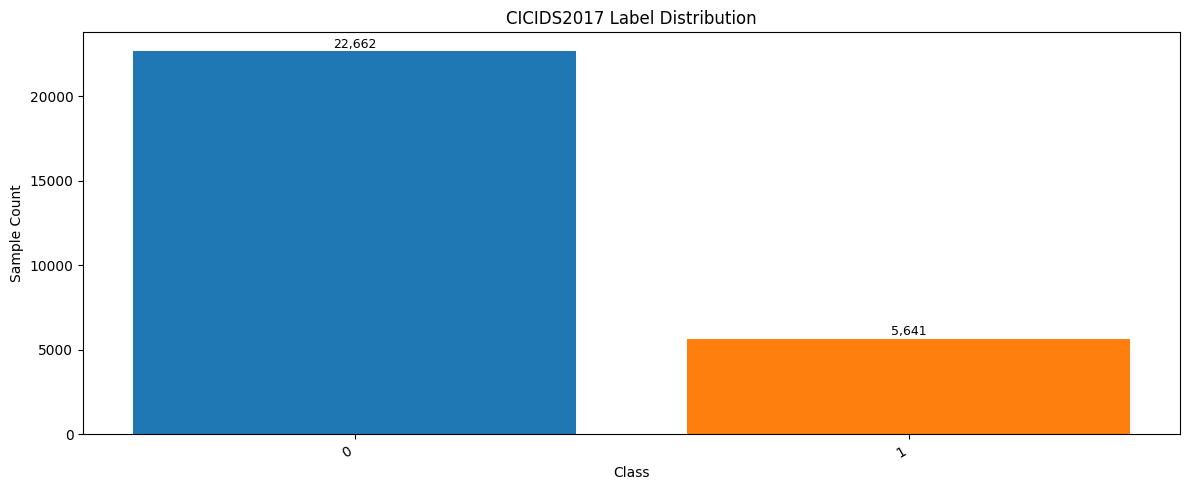

In [50]:
counts = df_cicids_2017['Label'].value_counts()
labels = [str(l) for l in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('CICIDS2017 Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Load NF-Ton-IoT-V2 data

In [51]:
# Read the NF-ToN-IoT-V2 dataset
df_nfton = pd.read_parquet('NF-Ton-IoT-V2/NF-ToN-IoT-V2.parquet')
df_nfton

,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,...,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack
0,49235,4444,6,0.000000,155392,202,34552,149,24,24,...,45555,4805,0,0,0,0,0,0,1,ransomware
1,49228,1880,6,0.000000,1600,40,35741,65,24,16,...,16425,237,0,0,0,0,0,0,0,Benign
2,0,0,1,0.000000,212,2,0,0,0,0,...,0,0,771,3,0,0,0,0,0,Benign
3,65317,1900,17,0.000000,165,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Benign
4,60766,15600,17,0.000000,63,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13135876,49200,4444,6,0.000000,152960,210,36392,163,24,24,...,16425,2385,0,0,0,0,0,0,1,ransomware
13135877,1880,49178,6,0.000000,31067,49,1160,29,24,24,...,237,16425,0,0,0,0,0,0,0,Benign
13135878,43,37796,6,170.000000,4275,5,296,5,25,25,...,453,1024,19200,75,0,0,0,0,0,Benign
13135879,443,49198,6,91.178001,191,4,151,3,25,25,...,64240,63846,0,0,0,0,0,0,0,Benign


In [52]:
print("NF-ToN-IoT-V2 shape:", df_nfton.shape)
# check the last few columns and label candidate
print(df_nfton.columns[-5:])
print("Last column:", df_nfton.columns[-1])

NF-ToN-IoT-V2 shape: (13135881, 43)
Index(['DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label',
       'Attack'],
      dtype='str')
Last column: Attack


In [53]:
# select label column
possible_label_cols = ['Label', 'label', 'Attack', 'attack', 'Category', 'category', 'Target', 'target', 'Description']

label_col_nfton = None
for col in possible_label_cols:
    if col in df_nfton.columns:
        label_col_nfton = col
        break

if label_col_nfton is None:
    label_col_nfton = df_nfton.columns[-1]

print("Selected label column:", label_col_nfton)

Selected label column: Label


In [54]:
# drop raw IP address columns
for col in ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR']:
    if col in df_nfton.columns:
        df_nfton.drop(columns=[col], inplace=True)

### Data pre-processing (NF-ToN-IoT-V2)

In [55]:
# Encode the dataset
labelencoder_nfton = LabelEncoder()
df_nfton[label_col_nfton] = labelencoder_nfton.fit_transform(df_nfton[label_col_nfton].astype(str))

In [56]:
# drop non-numeric feature columns
non_numeric_cols = df_nfton.drop(columns=[label_col_nfton]).select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric_cols:
    print("Dropping non-numeric columns:", non_numeric_cols)
    df_nfton.drop(columns=non_numeric_cols, inplace=True)

Dropping non-numeric columns: ['Attack']


In [57]:
# min-max normalization
for column in df_nfton.drop(columns=[label_col_nfton]).columns:
    col_min = df_nfton[column].min()
    col_max = df_nfton[column].max()

    if col_max != col_min:
        df_nfton[column] = (df_nfton[column] - col_min) / (col_max - col_min)
    else:
        df_nfton[column] = 0

In [58]:
# address empty values
if df_nfton.isnull().values.any() or np.isinf(df_nfton.select_dtypes(include=[np.number])).values.any():
    df_nfton.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_nfton.fillna(0, inplace=True)

In [59]:
X_nfton = df_nfton.drop(columns=[label_col_nfton])
y_nfton = df_nfton[label_col_nfton]

# 3-fold stratified cross-validation
cv_nfton = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [60]:

# stratified subset for practical benchmarking
X_nfton_sub, _, y_nfton_sub, _ = train_test_split(
    X_nfton,
    y_nfton,
    train_size=10000,   # s
    stratify=y_nfton,
    random_state=42
)

cv_nfton = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Original NFToN shape:", X_nfton.shape)
print("Subset NFToN shape:", X_nfton_sub.shape)
print("Class distribution in subset:")
print(pd.Series(y_nfton_sub).value_counts(normalize=True))

Original NFToN shape: (13135881, 41)
Subset NFToN shape: (10000, 41)
Class distribution in subset:
Label
1    0.7258
0    0.2742
Name: proportion, dtype: float64


In [61]:
#saving directory for NF-ToN models
NFToN_SUBDIR = f"{MODEL_DIR}/nfton"
os.makedirs(NFToN_SUBDIR, exist_ok=True)

### Data pre-processing (CICEVSE2024)

In [62]:
# Encode the dataset
labelencoder = LabelEncoder()
df_cicevse_2024.iloc[:, -1] = labelencoder.fit_transform(df_cicevse_2024.iloc[:, -1])

In [63]:
# min-max normalization
for column in df_cicevse_2024.columns[:-1]: # excluding the last column
    df_cicevse_2024[column] = (df_cicevse_2024[column] - df_cicevse_2024[column].min()) / (df_cicevse_2024[column].max() - df_cicevse_2024[column].min())

In [64]:
# address empty values
if df_cicevse_2024.isnull().values.any() or np.isinf(df_cicevse_2024).values.any():
    df_cicevse_2024.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cicevse_2024.fillna(0, inplace=True)

In [65]:
X_cicevse = df_cicevse_2024.drop(['Label'], axis=1)
y_cicevse = df_cicevse_2024.iloc[:, -1]

# 3-fold stratified cross-validation
cv_cicevse = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

### Data pre-processing (CICIDS2017)

In [66]:
# Encode string labels to integers
labelencoder_cicids = LabelEncoder()
df_cicids_2017['Label'] = labelencoder_cicids.fit_transform(df_cicids_2017['Label'])

In [67]:
# min-max normalization
for column in df_cicids_2017.columns[:-1]:
    col_range = df_cicids_2017[column].max() - df_cicids_2017[column].min()
    if col_range > 0:
        df_cicids_2017[column] = (df_cicids_2017[column] - df_cicids_2017[column].min()) / col_range
    else:
        df_cicids_2017[column] = 0

In [68]:
# address empty values
if df_cicids_2017.isnull().values.any() or np.isinf(df_cicids_2017.select_dtypes(include=[np.number])).values.any():
    df_cicids_2017.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cicids_2017.fillna(0, inplace=True)

In [69]:
X_cicids = df_cicids_2017.drop(['Label'], axis=1)
y_cicids = df_cicids_2017['Label']

# 3-fold stratified cross-validation
cv_cicids = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


In [70]:
print("CICEVSE first 10 cols:", list(X_cicevse.columns[:10]))
print("CICEVSE shape:", X_cicevse.shape)

print("CICIDS first 10 cols:", list(X_cicids.columns[:10]))
print("CICIDS shape:", X_cicids.shape)

print("NFToN first 10 cols:", list(X_nfton.columns[:10]))
print("NFToN shape:", X_nfton.shape)

CICEVSE first 10 cols: ['expiration_id', 'src_ip', 'src_mac', 'src_oui', 'src_port', 'dst_ip', 'dst_mac', 'dst_oui', 'dst_port', 'protocol']
CICEVSE shape: (35941, 85)
CICIDS first 10 cols: ['Flow Duration', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Min', 'Fwd Header Length']
CICIDS shape: (28303, 19)
NFToN first 10 cols: ['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS']
NFToN shape: (13135881, 41)


### Reference Models from Literature

| Paper | Link | Models |
|-------|------|--------|
| Tree-based Intelligent Intrusion Detection System in Internet of Vehicles | [arXiv:1910.08635](https://arxiv.org/pdf/1910.08635) | Random Forest, Decision Tree, Extra Tree, XGBoost |
| MTH-IDS: A Multitiered Hybrid Intrusion Detection System for Internet of Vehicles | [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9443234) | Multi-SVM, KNN |
|A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles| [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9838780) | VGG16, VGG19|
|Deep Learning Approach for Intelligent Intrusion Detection System| [IEEE Xplore](https://ieeexplore.ieee.org/abstract/document/8681044)| DNN, LR|
| | | LightGBM|


In [71]:
def _per_class_from_conf_matrix(conf_matrix, labels):
    """Derive per-class precision/recall/f1 from a summed confusion matrix."""
    per_class = {}
    for i, lbl in enumerate(labels):
        tp = conf_matrix[i, i]
        fp = conf_matrix[:, i].sum() - tp
        fn = conf_matrix[i, :].sum() - tp
        support = conf_matrix[i, :].sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        per_class[str(lbl)] = {"precision": prec, "recall": rec, "f1-score": f1, "support": float(support)}
    return per_class


def train_xgboost(
    X, y, cv,
    model_name: str = "XGBoost (default)",
    model_path: str = f"{MODEL_DIR}/xgboost.json",
) -> ModelResult:
    """Train XGBoost with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = xgb.XGBClassifier()
        model.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = xgb.XGBClassifier(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = xgb.XGBClassifier(random_state=42)
        model.fit(X, y)
        model.save_model(model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )




In [72]:
xgb_result = train_xgboost(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] XGBoost (default)", model_path=f"{CICEVSE_SUBDIR}/xgboost.json")
print(f"Done — {xgb_result.model_name}  |  Accuracy: {xgb_result.accuracy*100:.3f}% ± {xgb_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] XGBoost (default)...
  Fold 1: Accuracy=99.933%
  Fold 2: Training [CICEVSE] XGBoost (default)...
  Fold 2: Accuracy=99.900%
  Fold 3: Training [CICEVSE] XGBoost (default)...
  Fold 3: Accuracy=99.850%
Done — [CICEVSE] XGBoost (default)  |  Accuracy: 99.894% ± 0.034%


In [73]:
registry = _load_registry()

key = "[CICIDS] XGBoost (default)"
if key in registry:
    print("Removing stale entry:", key, "->", registry[key])
    del registry[key]
    _save_registry(registry)

In [74]:
xgb_result_cicids = train_xgboost(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] XGBoost (default)", model_path=f"{CICIDS_SUBDIR}/xgboost.json")
print(f"Done — {xgb_result_cicids.model_name}  |  Accuracy: {xgb_result_cicids.accuracy*100:.3f}% ± {xgb_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] XGBoost (default)...
  Fold 1: Accuracy=99.714%
  Fold 2: Training [CICIDS] XGBoost (default)...
  Fold 2: Accuracy=99.777%
  Fold 3: Training [CICIDS] XGBoost (default)...
  Fold 3: Accuracy=99.714%
Done — [CICIDS] XGBoost (default)  |  Accuracy: 99.735% ± 0.030%


In [75]:
registry = _load_registry()
if "[NFToN] XGBoost (default)" in registry:
    del registry["[NFToN] XGBoost (default)"]
_save_registry(registry)

In [76]:
xgb_result_nfton = train_xgboost(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] XGBoost (default)",
    model_path=f"{NFToN_SUBDIR}/xgboost.json"
)

  Fold 1: Training [NFToN] XGBoost (default)...
  Fold 1: Accuracy=98.350%
  Fold 2: Training [NFToN] XGBoost (default)...
  Fold 2: Accuracy=98.320%
  Fold 3: Training [NFToN] XGBoost (default)...
  Fold 3: Accuracy=97.990%


In [77]:
def train_random_forest(
    X, y, cv,
    model_name: str = "Random Forest",
    model_path: str = f"{MODEL_DIR}/random_forest.pkl",
) -> ModelResult:
    """Train Random Forest with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = RandomForestClassifier(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = RandomForestClassifier(random_state=42)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


rf_result = train_random_forest(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Random Forest", model_path=f"{CICEVSE_SUBDIR}/random_forest.pkl")
print(f"Done — {rf_result.model_name}  |  Accuracy: {rf_result.accuracy*100:.3f}% ± {rf_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Random Forest...
  Fold 1: Accuracy=99.883%
  Fold 2: Training [CICEVSE] Random Forest...
  Fold 2: Accuracy=99.900%
  Fold 3: Training [CICEVSE] Random Forest...
  Fold 3: Accuracy=99.775%
Done — [CICEVSE] Random Forest  |  Accuracy: 99.853% ± 0.056%


In [78]:
rf_result_cicids = train_random_forest(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Random Forest", model_path=f"{CICIDS_SUBDIR}/random_forest.pkl")
print(f"Done — {rf_result_cicids.model_name}  |  Accuracy: {rf_result_cicids.accuracy*100:.3f}% ± {rf_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Random Forest...
  Fold 1: Accuracy=99.650%
  Fold 2: Training [CICIDS] Random Forest...
  Fold 2: Accuracy=99.693%
  Fold 3: Training [CICIDS] Random Forest...
  Fold 3: Accuracy=99.682%
Done — [CICIDS] Random Forest  |  Accuracy: 99.675% ± 0.018%


In [156]:
rf_result_nfton = train_random_forest(
    X_nfton_sub, y_nfton_sub, cv_nfton, model_name="[NFToN] Random Forest", model_path=f"{NFToN_SUBDIR}/random_forest.pkl"
)
print(f"Done — {rf_result_nfton.model_name}  |  Accuracy: {rf_result_nfton.accuracy*100:.3f}% ± {rf_result_nfton.accuracy_std*100:.3f}%")   

  Fold 1: Training [NFToN] Random Forest...
  Fold 1: Accuracy=98.500%
  Fold 2: Training [NFToN] Random Forest...
  Fold 2: Accuracy=98.410%
  Fold 3: Training [NFToN] Random Forest...
  Fold 3: Accuracy=97.990%
Done — [NFToN] Random Forest  |  Accuracy: 98.300% ± 0.222%


In [79]:
def train_decision_tree(
    X, y, cv,
    model_name: str = "Decision Tree",
    model_path: str = f"{MODEL_DIR}/decision_tree.pkl",
) -> ModelResult:
    """Train Decision Tree with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = DecisionTreeClassifier(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = DecisionTreeClassifier(random_state=42)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


dt_result = train_decision_tree(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Decision Tree", model_path=f"{CICEVSE_SUBDIR}/decision_tree.pkl")
print(f"Done — {dt_result.model_name}  |  Accuracy: {dt_result.accuracy*100:.3f}% ± {dt_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Decision Tree...
  Fold 1: Accuracy=99.967%
  Fold 2: Training [CICEVSE] Decision Tree...
  Fold 2: Accuracy=99.967%
  Fold 3: Training [CICEVSE] Decision Tree...
  Fold 3: Accuracy=99.925%
Done — [CICEVSE] Decision Tree  |  Accuracy: 99.953% ± 0.020%


In [80]:
dt_result_cicids = train_decision_tree(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Decision Tree", model_path=f"{CICIDS_SUBDIR}/decision_tree.pkl")
print(f"Done — {dt_result_cicids.model_name}  |  Accuracy: {dt_result_cicids.accuracy*100:.3f}% ± {dt_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Decision Tree...
  Fold 1: Accuracy=99.502%
  Fold 2: Training [CICIDS] Decision Tree...
  Fold 2: Accuracy=99.544%
  Fold 3: Training [CICIDS] Decision Tree...
  Fold 3: Accuracy=99.470%
Done — [CICIDS] Decision Tree  |  Accuracy: 99.505% ± 0.030%


In [81]:
dt_result_nfton = train_decision_tree(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] Decision Tree",
    model_path=f"{NFToN_SUBDIR}/decision_tree.pkl"
)

  Fold 1: Training [NFToN] Decision Tree...
  Fold 1: Accuracy=97.600%
  Fold 2: Training [NFToN] Decision Tree...
  Fold 2: Accuracy=97.690%
  Fold 3: Training [NFToN] Decision Tree...
  Fold 3: Accuracy=97.510%


In [82]:
def train_extra_trees(
    X, y, cv,
    model_name: str = "Extra Trees",
    model_path: str = f"{MODEL_DIR}/extra_trees.pkl",
) -> ModelResult:
    """Train Extra Trees with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = ExtraTreesClassifier(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = ExtraTreesClassifier(random_state=42)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


et_result = train_extra_trees(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Extra Trees", model_path=f"{CICEVSE_SUBDIR}/extra_trees.pkl")
print(f"Done — {et_result.model_name}  |  Accuracy: {et_result.accuracy*100:.3f}% ± {et_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Extra Trees...
  Fold 1: Accuracy=99.775%
  Fold 2: Training [CICEVSE] Extra Trees...
  Fold 2: Accuracy=99.791%
  Fold 3: Training [CICEVSE] Extra Trees...
  Fold 3: Accuracy=99.624%
Done — [CICEVSE] Extra Trees  |  Accuracy: 99.730% ± 0.075%


In [83]:
et_result_cicids = train_extra_trees(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Extra Trees", model_path=f"{CICIDS_SUBDIR}/extra_trees.pkl")
print(f"Done — {et_result_cicids.model_name}  |  Accuracy: {et_result_cicids.accuracy*100:.3f}% ± {et_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Extra Trees...
  Fold 1: Accuracy=99.555%
  Fold 2: Training [CICIDS] Extra Trees...
  Fold 2: Accuracy=99.523%
  Fold 3: Training [CICIDS] Extra Trees...
  Fold 3: Accuracy=99.534%
Done — [CICIDS] Extra Trees  |  Accuracy: 99.537% ± 0.013%


In [84]:
et_result_nfton = train_extra_trees(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] Extra Trees",
    model_path=f"{NFToN_SUBDIR}/extra_trees.pkl"
)

  Fold 1: Training [NFToN] Extra Trees...
  Fold 1: Accuracy=98.290%
  Fold 2: Training [NFToN] Extra Trees...
  Fold 2: Accuracy=98.230%
  Fold 3: Training [NFToN] Extra Trees...
  Fold 3: Accuracy=97.810%


In [85]:
def train_svm(
    X, y, cv,
    model_name: str = "Svm",
    model_path: str = f"{MODEL_DIR}/svm.pkl",
) -> ModelResult:
    """Train SVM with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = SVC(random_state=42)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = SVC(random_state=42)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


svm_result = train_svm(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Multi-SVM", model_path=f"{CICEVSE_SUBDIR}/svm.pkl")
print(f"Done — {svm_result.model_name}  |  Accuracy: {svm_result.accuracy*100:.3f}% ± {svm_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Multi-SVM...
  Fold 1: Accuracy=59.452%
  Fold 2: Training [CICEVSE] Multi-SVM...
  Fold 2: Accuracy=59.599%
  Fold 3: Training [CICEVSE] Multi-SVM...
  Fold 3: Accuracy=59.533%
Done — [CICEVSE] Multi-SVM  |  Accuracy: 59.528% ± 0.060%


In [86]:
svm_result_cicids = train_svm(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Multi-SVM", model_path=f"{CICIDS_SUBDIR}/svm.pkl")
print(f"Done — {svm_result_cicids.model_name}  |  Accuracy: {svm_result_cicids.accuracy*100:.3f}% ± {svm_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Multi-SVM...
  Fold 1: Accuracy=93.365%
  Fold 2: Training [CICIDS] Multi-SVM...
  Fold 2: Accuracy=92.548%
  Fold 3: Training [CICIDS] Multi-SVM...
  Fold 3: Accuracy=92.898%
Done — [CICIDS] Multi-SVM  |  Accuracy: 92.937% ± 0.335%


In [87]:
svm_result_nfton = train_svm(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] Multi-SVM",
    model_path=f"{NFToN_SUBDIR}/svm.pkl"
)

  Fold 1: Training [NFToN] Multi-SVM...
  Fold 1: Accuracy=90.042%
  Fold 2: Training [NFToN] Multi-SVM...
  Fold 2: Accuracy=90.339%
  Fold 3: Training [NFToN] Multi-SVM...
  Fold 3: Accuracy=90.099%


In [88]:
def train_knn(
    X, y, cv,
    model_name: str = "Knn",
    model_path: str = f"{MODEL_DIR}/knn.pkl",
) -> ModelResult:
    """Train KNN with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = KNeighborsClassifier()

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = KNeighborsClassifier()
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


knn_result = train_knn(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] KNN", model_path=f"{CICEVSE_SUBDIR}/knn.pkl")
print(f"Done — {knn_result.model_name}  |  Accuracy: {knn_result.accuracy*100:.3f}% ± {knn_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] KNN...
  Fold 1: Accuracy=60.487%
  Fold 2: Training [CICEVSE] KNN...
  Fold 2: Accuracy=60.634%
  Fold 3: Training [CICEVSE] KNN...
  Fold 3: Accuracy=60.109%
Done — [CICEVSE] KNN  |  Accuracy: 60.410% ± 0.222%


In [89]:
knn_result_cicids = train_knn(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] KNN", model_path=f"{CICIDS_SUBDIR}/knn.pkl")
print(f"Done — {knn_result_cicids.model_name}  |  Accuracy: {knn_result_cicids.accuracy*100:.3f}% ± {knn_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] KNN...
  Fold 1: Accuracy=98.495%
  Fold 2: Training [CICIDS] KNN...
  Fold 2: Accuracy=98.516%
  Fold 3: Training [CICIDS] KNN...
  Fold 3: Accuracy=98.590%
Done — [CICIDS] KNN  |  Accuracy: 98.534% ± 0.041%


In [90]:
knn_result_nfton = train_knn(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] KNN",
    model_path=f"{NFToN_SUBDIR}/knn.pkl"
)

  Fold 1: Training [NFToN] KNN...
  Fold 1: Accuracy=94.331%
  Fold 2: Training [NFToN] KNN...
  Fold 2: Accuracy=93.939%
  Fold 3: Training [NFToN] KNN...
  Fold 3: Accuracy=94.059%


In [91]:
def train_logistic_regression(
    X, y, cv,
    model_name: str = "Logistic Regression",
    model_path: str = f"{MODEL_DIR}/logistic_regression.pkl",
) -> ModelResult:
    """Train Logistic Regression with stratified cross-validation."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    all_labels = sorted(np.unique(y))

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = joblib.load(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            print(f"  Fold {fold_i}: Training {model_name}...")
            model = LogisticRegression(random_state=42, max_iter=1000)

            start = time.time()
            model.fit(X_train, y_train)
            total_train_time += time.time() - start

            start = time.time()
            y_pred = model.predict(X_test)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full data and save
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X, y)
        joblib.dump(model, model_path)
        registry = _load_registry()
        registry[model_name] = {
            "training_time": total_train_time,
            "model_path": model_path,
        }
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


lr_result = train_logistic_regression(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] Logistic Regression", model_path=f"{CICEVSE_SUBDIR}/logistic_regression.pkl")
print(f"Done — {lr_result.model_name}  |  Accuracy: {lr_result.accuracy*100:.3f}% ± {lr_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] Logistic Regression...
  Fold 1: Accuracy=59.528%
  Fold 2: Training [CICEVSE] Logistic Regression...
  Fold 2: Accuracy=59.942%
  Fold 3: Training [CICEVSE] Logistic Regression...
  Fold 3: Accuracy=59.566%
Done — [CICEVSE] Logistic Regression  |  Accuracy: 59.678% ± 0.187%


In [92]:
lr_result_cicids = train_logistic_regression(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] Logistic Regression", model_path=f"{CICIDS_SUBDIR}/logistic_regression.pkl")
print(f"Done — {lr_result_cicids.model_name}  |  Accuracy: {lr_result_cicids.accuracy*100:.3f}% ± {lr_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] Logistic Regression...
  Fold 1: Accuracy=88.066%
  Fold 2: Training [CICIDS] Logistic Regression...
  Fold 2: Accuracy=88.287%
  Fold 3: Training [CICIDS] Logistic Regression...
  Fold 3: Accuracy=90.110%
Done — [CICIDS] Logistic Regression  |  Accuracy: 88.821% ± 0.916%


In [93]:
lr_result_nfton = train_logistic_regression(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] Logistic Regression",
    model_path=f"{NFToN_SUBDIR}/logistic_regression.pkl"
)

  Fold 1: Training [NFToN] Logistic Regression...
  Fold 1: Accuracy=72.915%
  Fold 2: Training [NFToN] Logistic Regression...
  Fold 2: Accuracy=72.877%
  Fold 3: Training [NFToN] Logistic Regression...
  Fold 3: Accuracy=73.177%


In [94]:
def train_dnn(
    X, y, cv,
    model_name: str = "DNN",
    model_path: str = f"{MODEL_DIR}/dnn.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """
    Deep Neural Network per the paper architecture:
    FC(1024)->BN->Drop -> FC(768)->BN->Drop -> FC(512)->BN->Drop
    -> FC(256)->BN->Drop -> FC(128)->BN->Drop -> FC(n_classes, softmax)
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            start = time.time()
            probs = model.predict(X_test.values, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features,))
                x = inp
                for units in [1024, 768, 512, 256, 128]:
                    x = layers.Dense(units, activation='relu')(x)
                    x = layers.BatchNormalization()(x)
                    x = layers.Dropout(0.01)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)

                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_train.values, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_test.values, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features,))
            x = inp
            for units in [1024, 768, 512, 256, 128]:
                x = layers.Dense(units, activation='relu')(x)
                x = layers.BatchNormalization()(x)
                x = layers.Dropout(0.01)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X.values, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


dnn_result = train_dnn(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] DNN", model_path=f"{CICEVSE_SUBDIR}/dnn.keras")
print(f"Done — {dnn_result.model_name}  |  Accuracy: {dnn_result.accuracy*100:.3f}% ± {dnn_result.accuracy_std*100:.3f}%")



  Fold 1: Training [CICEVSE] DNN on CPU
  Fold 1: Accuracy=56.656%
  Fold 2: Training [CICEVSE] DNN on CPU
  Fold 2: Accuracy=56.803%
  Fold 3: Training [CICEVSE] DNN on CPU
  Fold 3: Accuracy=52.638%
Done — [CICEVSE] DNN  |  Accuracy: 55.366% ± 1.930%


In [95]:
dnn_result_cicids = train_dnn(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] DNN", model_path=f"{CICIDS_SUBDIR}/dnn.keras")
print(f"Done — {dnn_result_cicids.model_name}  |  Accuracy: {dnn_result_cicids.accuracy*100:.3f}% ± {dnn_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] DNN on CPU
  Fold 1: Accuracy=96.418%
  Fold 2: Training [CICIDS] DNN on CPU
  Fold 2: Accuracy=96.597%
  Fold 3: Training [CICIDS] DNN on CPU
  Fold 3: Accuracy=96.057%
Done — [CICIDS] DNN  |  Accuracy: 96.357% ± 0.225%


In [96]:
dnn_result_nfton = train_dnn(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] DNN",
    model_path=f"{NFToN_SUBDIR}/dnn.keras"
)

  Fold 1: Training [NFToN] DNN on CPU
  Fold 1: Accuracy=93.761%
  Fold 2: Training [NFToN] DNN on CPU
  Fold 2: Accuracy=96.880%
  Fold 3: Training [NFToN] DNN on CPU
  Fold 3: Accuracy=96.010%


In [100]:
def train_vgg16_1d(
    X, y, cv,
    model_name: str = "VGG16 (1D-CNN)",
    model_path: str = f"{MODEL_DIR}/vgg16_1d.keras",
    epochs: int = 50,
    batch_size: int = 1024,
) -> ModelResult:
    """VGG16 adapted as a 1D-CNN for tabular input (features -> (features,1))."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def vgg_block_1d(x, filters, n_convs):
        for _ in range(n_convs):
            x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)

        seq_len = x.shape[1]
        if seq_len is not None and seq_len >= 2:
            x = layers.MaxPooling1D(pool_size=2)(x)

        return x

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features, 1))
                x = vgg_block_1d(inp, 64,  2)
                x = vgg_block_1d(x,  128, 2)
                x = vgg_block_1d(x,  256, 3)
                x = vgg_block_1d(x,  512, 3)
                x = vgg_block_1d(x,  512, 3)
                x = layers.GlobalAveragePooling1D()(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)
                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features, 1))
            x = vgg_block_1d(inp, 64,  2)
            x = vgg_block_1d(x,  128, 2)
            x = vgg_block_1d(x,  256, 3)
            x = vgg_block_1d(x,  512, 3)
            x = vgg_block_1d(x,  512, 3)
            x = layers.GlobalAveragePooling1D()(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


vgg16_result = train_vgg16_1d(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] VGG16 (1D-CNN)", model_path=f"{CICEVSE_SUBDIR}/vgg16_1d.keras")
print(f"Done — {vgg16_result.model_name}  |  Accuracy: {vgg16_result.accuracy*100:.3f}% ± {vgg16_result.accuracy_std*100:.3f}%")


Loading cached [CICEVSE] VGG16 (1D-CNN) from models/cicevse/vgg16_1d.keras
  Fold 1: Accuracy=60.312%
  Fold 2: Accuracy=60.492%
  Fold 3: Accuracy=60.242%
Done — [CICEVSE] VGG16 (1D-CNN)  |  Accuracy: 60.349% ± 0.105%


In [101]:
vgg16_result_cicids = train_vgg16_1d(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] VGG16 (1D-CNN)", model_path=f"{CICIDS_SUBDIR}/vgg16_1d.keras")
print(f"Done — {vgg16_result_cicids.model_name}  |  Accuracy: {vgg16_result_cicids.accuracy*100:.3f}% ± {vgg16_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] VGG16 (1D-CNN) on CPU
  Fold 1: Accuracy=97.382%
  Fold 2: Training [CICIDS] VGG16 (1D-CNN) on CPU
  Fold 2: Accuracy=96.788%
  Fold 3: Training [CICIDS] VGG16 (1D-CNN) on CPU
  Fold 3: Accuracy=96.990%
Done — [CICIDS] VGG16 (1D-CNN)  |  Accuracy: 97.053% ± 0.247%


In [102]:
vgg16_result_nfton = train_vgg16_1d(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] VGG16 (1D-CNN)",
    model_path=f"{NFToN_SUBDIR}/vgg16_1d.keras"
)

  Fold 1: Training [NFToN] VGG16 (1D-CNN) on CPU
  Fold 1: Accuracy=94.421%
  Fold 2: Training [NFToN] VGG16 (1D-CNN) on CPU
  Fold 2: Accuracy=95.380%
  Fold 3: Training [NFToN] VGG16 (1D-CNN) on CPU
  Fold 3: Accuracy=95.740%


In [107]:
def train_vgg19_1d(
    X, y, cv,
    model_name: str = "VGG19 (1D-CNN)",
    model_path: str = f"{MODEL_DIR}/vgg19_1d.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG19 adapted as a 1D-CNN. Blocks 3/4/5 use 4 Conv1D layers (vs 3 in VGG16)."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def vgg_block_1d(x, filters, n_convs):
        for _ in range(n_convs):
            x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)

            seq_len = x.shape[1]
        if seq_len is None or seq_len >= 2:
                x = layers.MaxPooling1D(pool_size=2, padding='same')(x)

        return x

    if model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                inp = tf.keras.Input(shape=(n_features, 1))
                x = vgg_block_1d(inp, 64,  2)
                x = vgg_block_1d(x,  128, 2)
                x = vgg_block_1d(x,  256, 4)   # VGG19: 4 convs
                x = vgg_block_1d(x,  512, 4)
                x = vgg_block_1d(x,  512, 4)
                x = layers.GlobalAveragePooling1D()(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                x = layers.Dense(1024, activation='relu')(x)
                x = layers.Dropout(0.5)(x)
                out = layers.Dense(n_classes, activation='softmax')(x)
                model = tf.keras.Model(inp, out)
                model.compile(optimizer='adam',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            inp = tf.keras.Input(shape=(n_features, 1))
            x = vgg_block_1d(inp, 64,  2)
            x = vgg_block_1d(x,  128, 2)
            x = vgg_block_1d(x,  256, 4)
            x = vgg_block_1d(x,  512, 4)
            x = vgg_block_1d(x,  512, 4)
            x = layers.GlobalAveragePooling1D()(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(1024, activation='relu')(x)
            x = layers.Dropout(0.5)(x)
            out = layers.Dense(n_classes, activation='softmax')(x)
            model = tf.keras.Model(inp, out)
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


vgg19_result = train_vgg19_1d(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] VGG19 (1D-CNN)", model_path=f"{CICEVSE_SUBDIR}/vgg19_1d.keras")
print(f"Done — {vgg19_result.model_name}  |  Accuracy: {vgg19_result.accuracy*100:.3f}% ± {vgg19_result.accuracy_std*100:.3f}%")


Loading cached [CICEVSE] VGG19 (1D-CNN) from models/cicevse/vgg19_1d.keras
  Fold 1: Accuracy=21.409%
  Fold 2: Accuracy=21.411%
  Fold 3: Accuracy=21.419%
Done — [CICEVSE] VGG19 (1D-CNN)  |  Accuracy: 21.413% ± 0.004%


In [108]:
vgg19_result_cicids = train_vgg19_1d(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] VGG19 (1D-CNN)", model_path=f"{CICIDS_SUBDIR}/vgg19_1d.keras")
print(f"Done — {vgg19_result_cicids.model_name}  |  Accuracy: {vgg19_result_cicids.accuracy*100:.3f}% ± {vgg19_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] VGG19 (1D-CNN) on CPU
  Fold 1: Accuracy=97.382%
  Fold 2: Training [CICIDS] VGG19 (1D-CNN) on CPU
  Fold 2: Accuracy=80.072%
  Fold 3: Training [CICIDS] VGG19 (1D-CNN) on CPU
  Fold 3: Accuracy=96.926%
Done — [CICIDS] VGG19 (1D-CNN)  |  Accuracy: 91.460% ± 8.055%


In [109]:
vgg19_result_nfton = train_vgg19_1d(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] VGG19 (1D-CNN)",
    model_path=f"{NFToN_SUBDIR}/vgg19_1d.keras"
)

  Fold 1: Training [NFToN] VGG19 (1D-CNN) on CPU
  Fold 1: Accuracy=95.801%
  Fold 2: Training [NFToN] VGG19 (1D-CNN) on CPU
  Fold 2: Accuracy=72.577%
  Fold 3: Training [NFToN] VGG19 (1D-CNN) on CPU
  Fold 3: Accuracy=72.577%


In [110]:
def train_cnn(
    X, y, cv,
    model_name: str = "CNN",
    model_path: str = f"{MODEL_DIR}/cnn.keras",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """
    1-D CNN for tabular input (features -> (features, 1)).
    Architecture from CICEVSE2024 DL example:
      Conv1D(64,5)+BN -> Conv1D(64,3)+BN -> MaxPool -> Drop
      Conv1D(128,5)+BN -> Conv1D(128,3)+BN -> MaxPool -> Drop
      Conv1D(256,3)+BN -> Conv1D(256,3)+BN -> GlobalMaxPool
      Dense(256)+BN+Drop -> Dense(128)+Drop -> Dense(n_classes, softmax)
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    def _build_cnn(n_features, n_classes):
        inp = tf.keras.Input(shape=(n_features, 1))
        # Block 1
        x = layers.Conv1D(64, 5, padding='same', activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(0.15)(x)
        # Block 2
        x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(0.20)(x)
        # Block 3
        x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.20)(x)
        x = layers.GlobalMaxPooling1D()(x)
        # Dense head
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.25)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.15)(x)
        out = layers.Dense(n_classes, activation='softmax')(x)
        model = tf.keras.Model(inp, out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        return model

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = X_test.values.reshape(-1, n_features, 1)
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = X_train.values.reshape(-1, n_features, 1)
            X_te = X_test.values.reshape(-1, n_features, 1)

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                model = _build_cnn(n_features, n_classes)

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = X.values.reshape(-1, n_features, 1)
        with tf_strategy.scope():
            model = _build_cnn(n_features, n_classes)
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


cnn_result = train_cnn(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] CNN", model_path=f"{CICEVSE_SUBDIR}/cnn.keras")
print(f"Done — {cnn_result.model_name}  |  Accuracy: {cnn_result.accuracy*100:.3f}% ± {cnn_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] CNN on CPU
  Fold 1: Accuracy=58.576%
  Fold 2: Training [CICEVSE] CNN on CPU
  Fold 2: Accuracy=60.242%
  Fold 3: Training [CICEVSE] CNN on CPU
  Fold 3: Accuracy=55.902%
Done — [CICEVSE] CNN  |  Accuracy: 58.240% ± 1.788%


In [111]:
cnn_result_cicids = train_cnn(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] CNN", model_path=f"{CICIDS_SUBDIR}/cnn.keras")
print(f"Done — {cnn_result_cicids.model_name}  |  Accuracy: {cnn_result_cicids.accuracy*100:.3f}% ± {cnn_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] CNN on CPU
  Fold 1: Accuracy=96.502%
  Fold 2: Training [CICIDS] CNN on CPU
  Fold 2: Accuracy=97.149%
  Fold 3: Training [CICIDS] CNN on CPU
  Fold 3: Accuracy=97.657%
Done — [CICIDS] CNN  |  Accuracy: 97.103% ± 0.473%


In [112]:
cnn_result_nfton = train_cnn(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] CNN",
    model_path=f"{NFToN_SUBDIR}/cnn.keras"
)

  Fold 1: Training [NFToN] CNN on CPU
  Fold 1: Accuracy=87.343%
  Fold 2: Training [NFToN] CNN on CPU
  Fold 2: Accuracy=97.150%
  Fold 3: Training [NFToN] CNN on CPU
  Fold 3: Accuracy=80.078%


In [113]:
def train_lstm(
    X, y, cv,
    model_name: str = "LSTM",
    model_path: str = f"{MODEL_DIR}/lstm.keras",
    epochs: int = 60,
    batch_size: int = 256,
    chunk_size: int = 5,
) -> ModelResult:
    """
    LSTM for tabular input using chunked feature sequences.
    Features are grouped into chunks of `chunk_size` to form a sequence,
    then processed by: Dense(32) projection -> LSTM(64) -> Dense(64) -> Dense(n_classes).
    """
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    n_classes = len(np.unique(y))
    n_features = X.shape[1]
    all_labels = sorted(np.unique(y))

    # Compute padding so n_features is divisible by chunk_size
    remainder = n_features % chunk_size
    pad_width = 0 if remainder == 0 else (chunk_size - remainder)
    timesteps = (n_features + pad_width) // chunk_size

    def _reshape_for_lstm(arr):
        if pad_width > 0:
            arr = np.concatenate([arr, np.zeros((arr.shape[0], pad_width), dtype=np.float32)], axis=1)
        return arr.reshape((arr.shape[0], timesteps, chunk_size))

    def _build_lstm(timesteps, step_features, n_classes):
        inp = tf.keras.Input(shape=(timesteps, step_features))
        x = layers.Dense(32, activation='relu')(inp)
        x = layers.Dropout(0.10)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.15)(x)
        out = layers.Dense(n_classes, activation='softmax')(x)
        model = tf.keras.Model(inp, out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        return model

    if  model_name in registry and os.path.exists(registry[model_name]["model_path"]):
        entry = registry[model_name]
        print(f"Loading cached {model_name} from {entry['model_path']}")
        model = tf.keras.models.load_model(entry["model_path"])
        total_train_time = entry["training_time"]
        for fold_i, (_, test_idx) in enumerate(cv.split(X, y), 1):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]
            X_te = _reshape_for_lstm(X_test.values.astype(np.float32))
            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)
            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)
            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")
    else:
        total_train_time = 0.0

        for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            X_tr = _reshape_for_lstm(X_train.values.astype(np.float32))
            X_te = _reshape_for_lstm(X_test.values.astype(np.float32))

            tf.keras.backend.clear_session()

            with tf_strategy.scope():
                model = _build_lstm(timesteps, chunk_size, n_classes)

            print(f"  Fold {fold_i}: Training {model_name} on {tf_device}")
            start = time.time()
            model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
                      validation_split=0.1, verbose=0)
            total_train_time += time.time() - start

            start = time.time()
            probs = model.predict(X_te, verbose=0)
            total_infer_time += time.time() - start
            total_test_samples += len(X_test)
            y_pred = np.argmax(probs, axis=1)

            fold_acc.append(accuracy_score(y_test, y_pred))
            p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
            fold_prec.append(p); fold_rec.append(r); fold_f1.append(f)

            cm = confusion_matrix(y_test, y_pred, labels=all_labels)
            fold_conf = cm if fold_conf is None else fold_conf + cm
            print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}%")

        # Retrain on full dataset and save
        tf.keras.backend.clear_session()
        X_full = _reshape_for_lstm(X.values.astype(np.float32))
        with tf_strategy.scope():
            model = _build_lstm(timesteps, chunk_size, n_classes)
        model.fit(X_full, y.values, epochs=epochs, batch_size=batch_size, verbose=0)
        model.save(model_path)
        registry = _load_registry()
        registry[model_name] = {"training_time": total_train_time, "model_path": model_path}
        _save_registry(registry)

    return ModelResult(
        model_name=model_name, training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)), precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)), f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)), precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)), f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )


lstm_result = train_lstm(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] LSTM", model_path=f"{CICEVSE_SUBDIR}/lstm.keras")
print(f"Done — {lstm_result.model_name}  |  Accuracy: {lstm_result.accuracy*100:.3f}% ± {lstm_result.accuracy_std*100:.3f}%")

  Fold 1: Training [CICEVSE] LSTM on CPU
  Fold 1: Accuracy=60.078%
  Fold 2: Training [CICEVSE] LSTM on CPU
  Fold 2: Accuracy=60.175%
  Fold 3: Training [CICEVSE] LSTM on CPU
  Fold 3: Accuracy=60.267%
Done — [CICEVSE] LSTM  |  Accuracy: 60.174% ± 0.077%


In [114]:
lstm_result_cicids = train_lstm(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] LSTM", model_path=f"{CICIDS_SUBDIR}/lstm.keras")
print(f"Done — {lstm_result_cicids.model_name}  |  Accuracy: {lstm_result_cicids.accuracy*100:.3f}% ± {lstm_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training [CICIDS] LSTM on CPU
  Fold 1: Accuracy=95.029%
  Fold 2: Training [CICIDS] LSTM on CPU
  Fold 2: Accuracy=93.545%
  Fold 3: Training [CICIDS] LSTM on CPU
  Fold 3: Accuracy=95.601%
Done — [CICIDS] LSTM  |  Accuracy: 94.725% ± 0.867%


In [115]:
lstm_result_nfton = train_lstm(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] LSTM",
    model_path=f"{NFToN_SUBDIR}/lstm.keras"
)

  Fold 1: Training [NFToN] LSTM on CPU
  Fold 1: Accuracy=95.531%
  Fold 2: Training [NFToN] LSTM on CPU
  Fold 2: Accuracy=94.119%
  Fold 3: Training [NFToN] LSTM on CPU
  Fold 3: Accuracy=95.110%


In [130]:
from sklearn.model_selection import RandomizedSearchCV

def train_lightgbm(
    X, y, cv,
    model_name: str = "Lightgbm",
    model_path: str = f"{MODEL_DIR}/lightgbm.pkl",
) -> ModelResult:
    """Train LightGBM with stratified cross-validation and lightweight tuning."""
    registry = _load_registry()
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    fold_conf = None
    total_infer_time = 0.0
    total_test_samples = 0
    total_train_time = 0.0
    all_labels = sorted(np.unique(y))

    param_dist = {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "num_leaves": [15, 31],
        "max_depth": [6, 10, -1],
        "min_child_samples": [20, 40],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
    }

    for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        print(f"  Fold {fold_i}: Training and tuning {model_name}...")

        base_model = lgb.LGBMClassifier(
            random_state=42,
            verbose=-1
        )

        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_dist,
            n_iter=12,
            scoring='f1_weighted',
            cv=3,
            random_state=42,
            n_jobs=-1,
            verbose=0
        )

        start = time.time()
        search.fit(X_train, y_train)
        total_train_time += time.time() - start

        model = search.best_estimator_
        print(f"    Best params: {search.best_params_}")

        start = time.time()
        y_pred = model.predict(X_test)
        total_infer_time += time.time() - start
        total_test_samples += len(X_test)

        fold_acc.append(accuracy_score(y_test, y_pred))
        p, r, f, _ = precision_recall_fscore_support(
            y_test, y_pred, average='weighted', zero_division=0
        )
        fold_prec.append(p)
        fold_rec.append(r)
        fold_f1.append(f)

        cm = confusion_matrix(y_test, y_pred, labels=all_labels)
        fold_conf = cm if fold_conf is None else fold_conf + cm

        print(f"  Fold {fold_i}: Accuracy={fold_acc[-1]*100:.3f}% | Weighted F1={fold_f1[-1]*100:.3f}%")

    print(f"Retraining {model_name} on full dataset using a final lightweight search...")

    final_search = RandomizedSearchCV(
        estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
        param_distributions=param_dist,
        n_iter=12,
        scoring='f1_weighted',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    final_search.fit(X, y)
    final_model = final_search.best_estimator_

    print(f"Final best params: {final_search.best_params_}")

    joblib.dump(final_model, model_path)
    registry = _load_registry()
    registry[model_name] = {
        "training_time": total_train_time,
        "model_path": model_path,
        "best_params": final_search.best_params_,
    }
    _save_registry(registry)

    return ModelResult(
        model_name=model_name,
        training_time_s=total_train_time,
        inference_time_ms=total_infer_time / total_test_samples * 1000,
        accuracy=float(np.mean(fold_acc)),
        precision=float(np.mean(fold_prec)),
        recall=float(np.mean(fold_rec)),
        f1_score=float(np.mean(fold_f1)),
        accuracy_std=float(np.std(fold_acc)),
        precision_std=float(np.std(fold_prec)),
        recall_std=float(np.std(fold_rec)),
        f1_score_std=float(np.std(fold_f1)),
        confusion_matrix=fold_conf.tolist(),
        per_class_metrics=_per_class_from_conf_matrix(fold_conf, all_labels),
    )
lgb_result_cicevse = train_lightgbm(X_cicevse, y_cicevse, cv_cicevse, model_name="[CICEVSE] LightGBM", model_path=f"{CICEVSE_SUBDIR}/lightgbm.pkl")
print(f"Done — {lgb_result_cicevse.model_name}  |  Accuracy: {lgb_result_cicevse.accuracy*100:.3f}% ± {lgb_result_cicevse.accuracy_std*100:.3f}%")

  Fold 1: Training and tuning [CICEVSE] LightGBM...
    Best params: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Fold 1: Accuracy=99.942% | Weighted F1=99.942%
  Fold 2: Training and tuning [CICEVSE] LightGBM...
    Best params: {'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
  Fold 2: Accuracy=99.925% | Weighted F1=99.926%
  Fold 3: Training and tuning [CICEVSE] LightGBM...
    Best params: {'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
  Fold 3: Accuracy=99.891% | Weighted F1=99.891%
Retraining [CICEVSE] LightGBM on full dataset using a final lightweight search...
Final best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': -1, 'l

In [131]:
lgb_result_cicids = train_lightgbm(X_cicids, y_cicids, cv_cicids, model_name="[CICIDS] LightGBM", model_path=f"{CICIDS_SUBDIR}/lightgbm.pkl")
print(f"Done — {lgb_result_cicids.model_name}  |  Accuracy: {lgb_result_cicids.accuracy*100:.3f}% ± {lgb_result_cicids.accuracy_std*100:.3f}%")

  Fold 1: Training and tuning [CICIDS] LightGBM...
    Best params: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Fold 1: Accuracy=99.788% | Weighted F1=99.788%
  Fold 2: Training and tuning [CICIDS] LightGBM...
    Best params: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Fold 2: Accuracy=99.799% | Weighted F1=99.799%
  Fold 3: Training and tuning [CICIDS] LightGBM...
    Best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
  Fold 3: Accuracy=99.735% | Weighted F1=99.735%
Retraining [CICIDS] LightGBM on full dataset using a final lightweight search...
Final best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': -1, 'learni

In [132]:
lgb_result_nfton = train_lightgbm(
    X_nfton_sub, y_nfton_sub, cv_nfton,
    model_name="[NFToN] LightGBM",
    model_path=f"{NFToN_SUBDIR}/lightgbm.pkl"
)

  Fold 1: Training and tuning [NFToN] LightGBM...
    Best params: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Fold 1: Accuracy=98.530% | Weighted F1=98.528%
  Fold 2: Training and tuning [NFToN] LightGBM...
    Best params: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Fold 2: Accuracy=98.680% | Weighted F1=98.677%
  Fold 3: Training and tuning [NFToN] LightGBM...
    Best params: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Fold 3: Accuracy=98.110% | Weighted F1=98.102%
Retraining [NFToN] LightGBM on full dataset using a final lightweight search...
Final best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 40, 'max_depth': -1, 'learning_ra

In [157]:
# Ensure "dataset" field is set for all registry entries
registry = _load_registry()
for key in registry:
    if key.startswith("[CICEVSE]") and "dataset" not in registry[key]:
        registry[key]["dataset"] = "cicevse"
    elif key.startswith("[CICIDS]") and "dataset" not in registry[key]:
        registry[key]["dataset"] = "cicids"
    elif key.startswith("[NFToN]") and "dataset" not in registry[key]:
        registry[key]["dataset"] = "nfton"
_save_registry(registry)

In [158]:
# Accumulate all ModelResult objects — add/remove entries here as needed
results_cicevse: List[ModelResult] = [
    xgb_result,
    rf_result,
    dt_result,
    et_result,
    svm_result,
    knn_result,
    lr_result,
    dnn_result,
    vgg16_result,
    vgg19_result,
    cnn_result,
    lstm_result,
    lgb_result_cicevse
]

summary_df_cicevse = pd.DataFrame([r.to_summary_dict() for r in results_cicevse]).set_index('Model')
display(summary_df_cicevse.style
    .format(precision=4)
    .highlight_max(subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)' ], color='darkgreen')
    .highlight_min(subset=['Train Time (s)', 'Infer. Time (ms/sample)'], color='darkblue')
    .set_caption("CICEVSE2024 — 3-Fold Stratified CV — Model Comparison Summary")
)

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Train Time (s),Infer. Time (ms/sample)
Model,,,,,,
[CICEVSE] XGBoost (default),99.894 ± 0.034,99.896 ± 0.035,99.894 ± 0.034,99.895 ± 0.035,2.3800,0.0008
[CICEVSE] Random Forest,99.853 ± 0.056,99.857 ± 0.055,99.853 ± 0.056,99.854 ± 0.056,3.6200,0.0086
[CICEVSE] Decision Tree,99.953 ± 0.020,99.953 ± 0.020,99.953 ± 0.020,99.952 ± 0.020,0.3130,0.0004
[CICEVSE] Extra Trees,99.730 ± 0.075,99.732 ± 0.074,99.730 ± 0.075,99.731 ± 0.074,2.3970,0.0093
[CICEVSE] Multi-SVM,59.528 ± 0.060,60.801 ± 4.580,59.528 ± 0.060,50.495 ± 0.098,27.6440,1.0758
[CICEVSE] KNN,60.410 ± 0.222,59.425 ± 0.308,60.410 ± 0.222,59.475 ± 0.286,0.0200,0.0544
[CICEVSE] Logistic Regression,59.678 ± 0.187,60.392 ± 5.712,59.678 ± 0.187,53.482 ± 0.190,8.9720,0.0003
[CICEVSE] DNN,55.366 ± 1.930,60.686 ± 0.473,55.366 ± 1.930,50.610 ± 0.828,185.1330,0.0470
[CICEVSE] VGG16 (1D-CNN),60.349 ± 0.105,73.016 ± 0.144,60.349 ± 0.105,54.361 ± 0.106,1086.5040,0.3341


In [159]:
# Accumulate all CICIDS2017 ModelResult objects
results_cicids: List[ModelResult] = [
    xgb_result_cicids,
    rf_result_cicids,
    dt_result_cicids,
    et_result_cicids,
    svm_result_cicids,
    knn_result_cicids,
    lr_result_cicids,
    dnn_result_cicids,
    vgg16_result_cicids,
    vgg19_result_cicids,
    cnn_result_cicids,
    lstm_result_cicids,
    lgb_result_cicids,
]

summary_df_cicids = pd.DataFrame([r.to_summary_dict() for r in results_cicids]).set_index('Model')
display(summary_df_cicids.style
    .format(precision=4)
    .highlight_max(subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'], color='darkgreen')
    .highlight_min(subset=['Train Time (s)', 'Infer. Time (ms/sample)'], color='darkblue')
    .set_caption("CICIDS2017 — 3-Fold Stratified CV — Model Comparison Summary")
)

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Train Time (s),Infer. Time (ms/sample)
Model,,,,,,
[CICIDS] XGBoost (default),99.735 ± 0.030,99.735 ± 0.030,99.735 ± 0.030,99.735 ± 0.030,0.1860,0.0003
[CICIDS] Random Forest,99.675 ± 0.018,99.675 ± 0.018,99.675 ± 0.018,99.675 ± 0.018,2.7630,0.0031
[CICIDS] Decision Tree,99.505 ± 0.030,99.508 ± 0.028,99.505 ± 0.030,99.506 ± 0.030,0.2000,0.0002
[CICIDS] Extra Trees,99.537 ± 0.013,99.537 ± 0.013,99.537 ± 0.013,99.537 ± 0.013,1.1520,0.0052
[CICIDS] Multi-SVM,92.937 ± 0.335,92.759 ± 0.356,92.937 ± 0.335,92.754 ± 0.328,3.4040,0.1459
[CICIDS] KNN,98.534 ± 0.041,98.536 ± 0.040,98.534 ± 0.041,98.535 ± 0.041,0.0090,0.0052
[CICIDS] Logistic Regression,88.821 ± 0.916,88.623 ± 0.822,88.821 ± 0.916,87.711 ± 1.303,0.0860,0.0002
[CICIDS] DNN,96.357 ± 0.225,96.416 ± 0.179,96.357 ± 0.225,96.378 ± 0.210,141.4010,0.0494
[CICIDS] VGG16 (1D-CNN),97.053 ± 0.247,97.191 ± 0.174,97.053 ± 0.247,97.091 ± 0.230,455.2050,0.2730


In [160]:
# NF-ToN-IoT-V2 summary
results_nfton = [
    xgb_result_nfton,
    rf_result_nfton,
    dt_result_nfton,
    et_result_nfton,
    svm_result_nfton,
    knn_result_nfton,
    lr_result_nfton,
    dnn_result_nfton,
    vgg16_result_nfton,
    vgg19_result_nfton,
    cnn_result_nfton,
    lstm_result_nfton,
    lgb_result_nfton
]
summary_df_nfton = pd.DataFrame([r.to_summary_dict() for r in results_nfton]).set_index('Model')
summary_df_nfton

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Train Time (s),Infer. Time (ms/sample)
Model,,,,,,
[NFToN] XGBoost (default),98.220 ± 0.163,98.217 ± 0.163,98.220 ± 0.163,98.215 ± 0.166,0.155,0.0008
[NFToN] Random Forest,98.300 ± 0.222,98.298 ± 0.221,98.300 ± 0.222,98.294 ± 0.226,0.978,0.0058
[NFToN] Decision Tree,97.600 ± 0.073,97.610 ± 0.075,97.600 ± 0.073,97.603 ± 0.074,0.120,0.0005
[NFToN] Extra Trees,98.110 ± 0.214,98.108 ± 0.212,98.110 ± 0.214,98.102 ± 0.218,0.573,0.0077
[NFToN] Multi-SVM,90.160 ± 0.129,90.024 ± 0.139,90.160 ± 0.129,89.922 ± 0.126,1.123,0.0988
[NFToN] KNN,94.110 ± 0.164,94.174 ± 0.102,94.110 ± 0.164,93.973 ± 0.199,0.006,0.0036
[NFToN] Logistic Regression,72.990 ± 0.133,68.584 ± 0.468,72.990 ± 0.133,64.981 ± 0.232,0.083,0.0004
[NFToN] DNN,95.550 ± 1.314,95.724 ± 1.105,95.550 ± 1.314,95.581 ± 1.255,58.882,0.0782
[NFToN] VGG16 (1D-CNN),95.180 ± 0.556,95.278 ± 0.608,95.180 ± 0.556,95.073 ± 0.561,252.210,0.3544


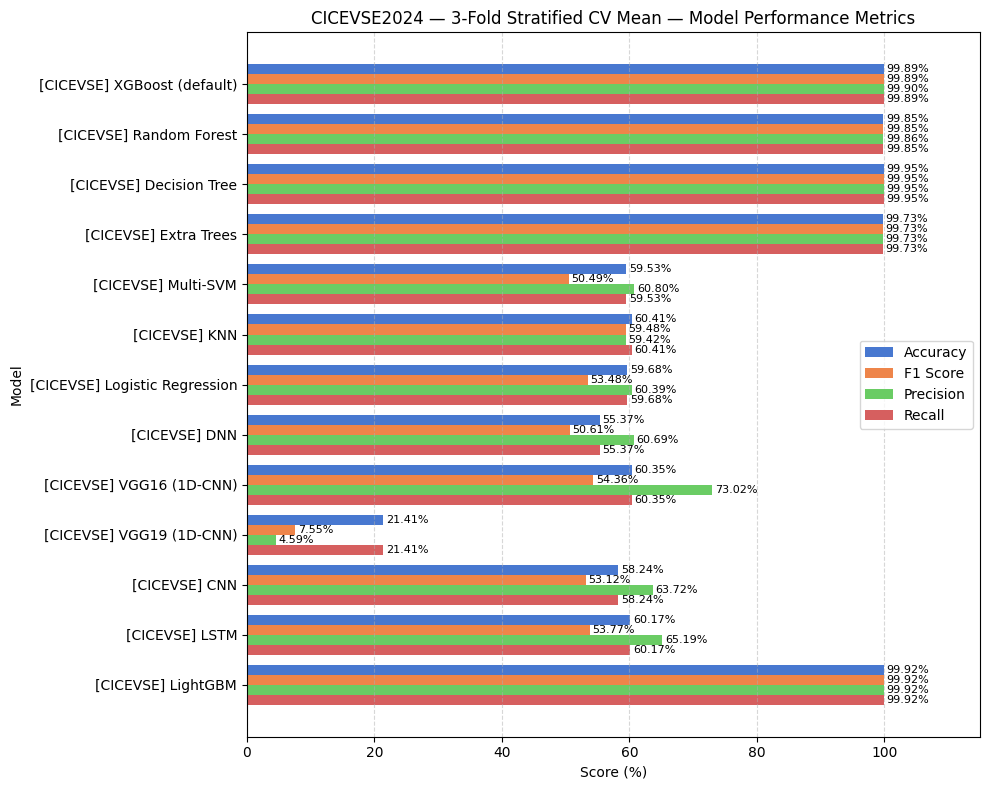

In [161]:
names     = [r.model_name for r in results_cicevse]
acc       = [r.accuracy   * 100 for r in results_cicevse]
f1        = [r.f1_score   * 100 for r in results_cicevse]
precision = [r.precision  * 100 for r in results_cicevse]
recall    = [r.recall     * 100 for r in results_cicevse]

metrics      = [acc, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors       = sns.color_palette('muted', 4)

y      = np.arange(len(names))
height = 0.2

fig, ax = plt.subplots(figsize=(10, 8))
for i, (vals, label, color) in enumerate(zip(metrics, metric_names, colors)):
    bars = ax.barh(y + i * height, vals, height, label=label, color=color)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.4, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=8)

ax.set_ylabel('Model')
ax.set_xlabel('Score (%)')
ax.set_title('CICEVSE2024 — 3-Fold Stratified CV Mean — Model Performance Metrics')
ax.set_yticks(y + height * (len(metrics) - 1) / 2)
ax.set_yticklabels(names)
ax.set_xlim(0, 115)
ax.invert_yaxis()
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

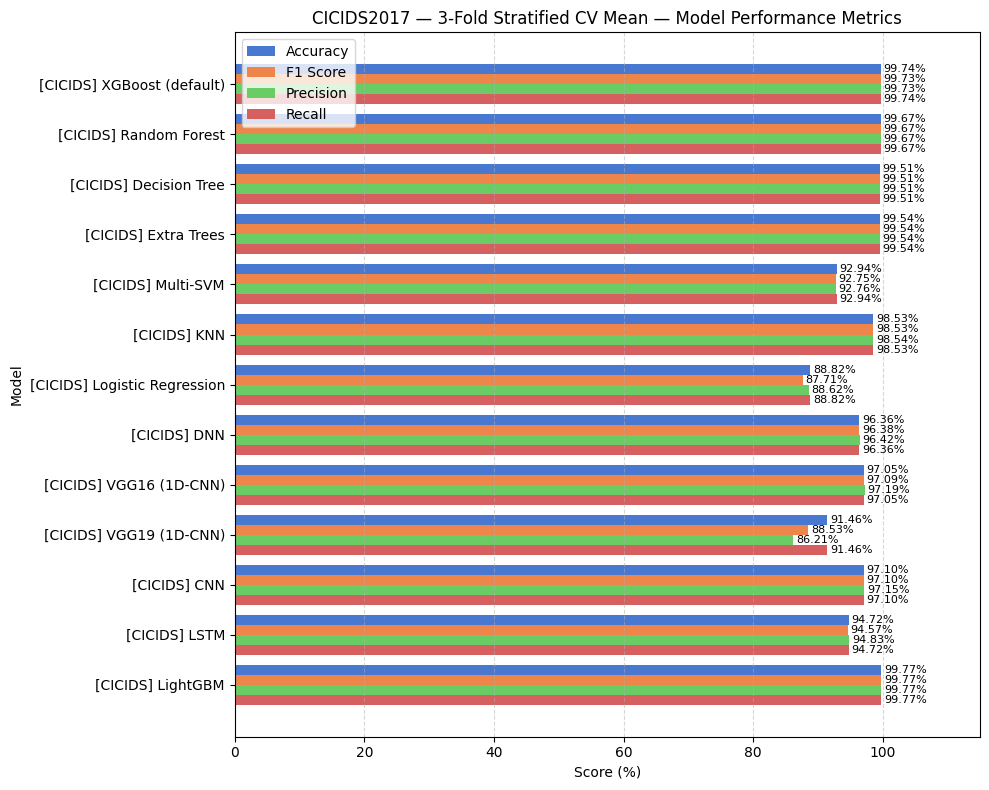

In [162]:
names_cicids = [r.model_name for r in results_cicids]
acc       = [r.accuracy   * 100 for r in results_cicids]
f1        = [r.f1_score   * 100 for r in results_cicids]
precision = [r.precision  * 100 for r in results_cicids]
recall    = [r.recall     * 100 for r in results_cicids]

metrics      = [acc, f1, precision, recall]
metric_names = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors       = sns.color_palette('muted', 4)

y      = np.arange(len(names_cicids))
height = 0.2

fig, ax = plt.subplots(figsize=(10, 8))
for i, (vals, label, color) in enumerate(zip(metrics, metric_names, colors)):
    bars = ax.barh(y + i * height, vals, height, label=label, color=color)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.4, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=8)

ax.set_ylabel('Model')
ax.set_xlabel('Score (%)')
ax.set_title('CICIDS2017 — 3-Fold Stratified CV Mean — Model Performance Metrics')
ax.set_yticks(y + height * (len(metrics) - 1) / 2)
ax.set_yticklabels(names_cicids)
ax.set_xlim(0, 115)
ax.invert_yaxis()
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

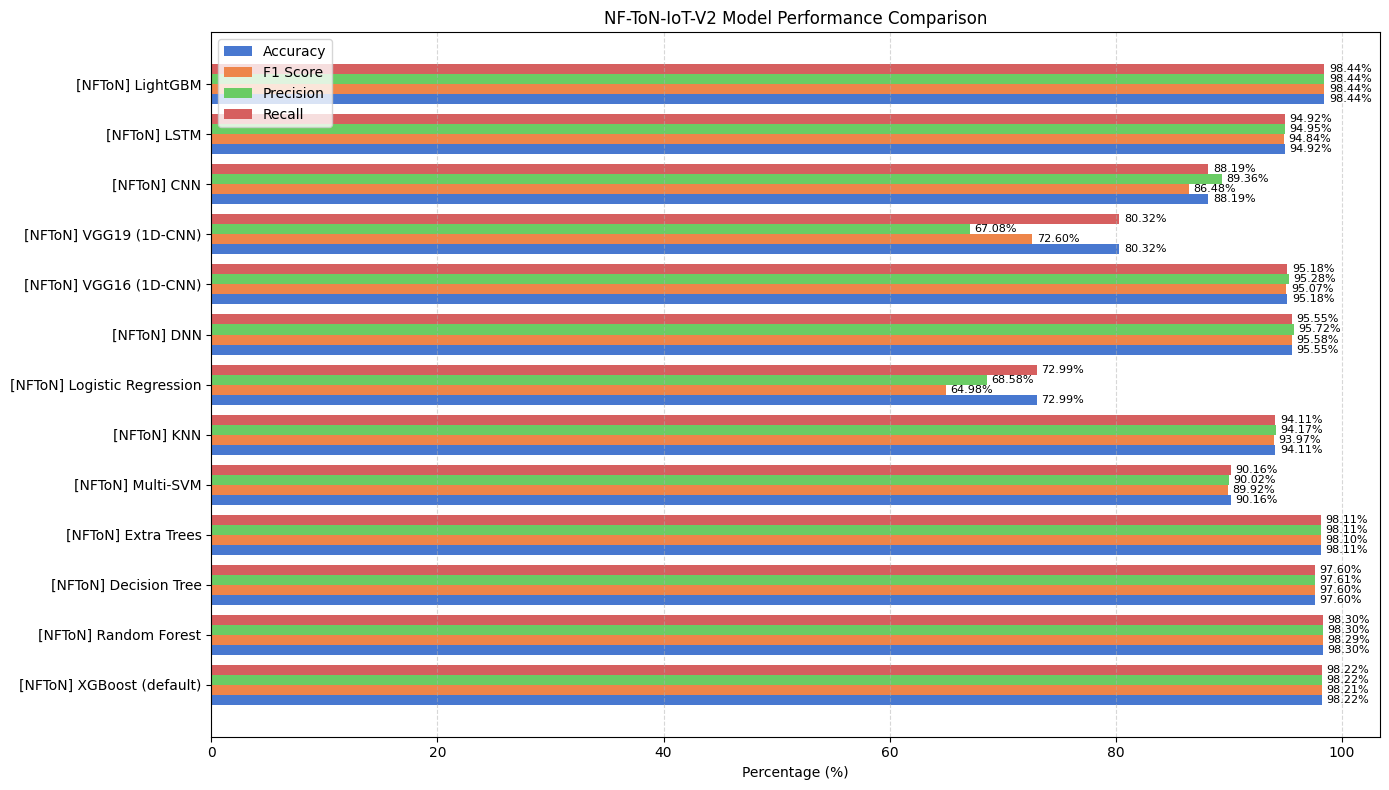

In [163]:
names_nfton = [r.model_name for r in results_nfton]
acc_nfton = [r.accuracy * 100 for r in results_nfton]
f1_nfton = [r.f1_score * 100 for r in results_nfton]
precision_nfton = [r.precision * 100 for r in results_nfton]
recall_nfton = [r.recall * 100 for r in results_nfton]

metrics_nfton = [acc_nfton, f1_nfton, precision_nfton, recall_nfton]
metric_names_nfton = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors_nfton = sns.color_palette('muted', 4)

y_pos = np.arange(len(names_nfton))
height = 0.2

fig, ax = plt.subplots(figsize=(14, 8))

for i, (metric, metric_name, color) in enumerate(zip(metrics_nfton, metric_names_nfton, colors_nfton)):
    bars = ax.barh(y_pos + i * height, metric, height=height, label=metric_name, color=color)
    for bar, val in zip(bars, metric):
        ax.text(val + 0.4, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=8)


ax.set_yticks(y_pos + height * 1.5)
ax.set_yticklabels(names_nfton)
ax.set_xlabel('Percentage (%)')
ax.set_title('NF-ToN-IoT-V2 Model Performance Comparison')
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

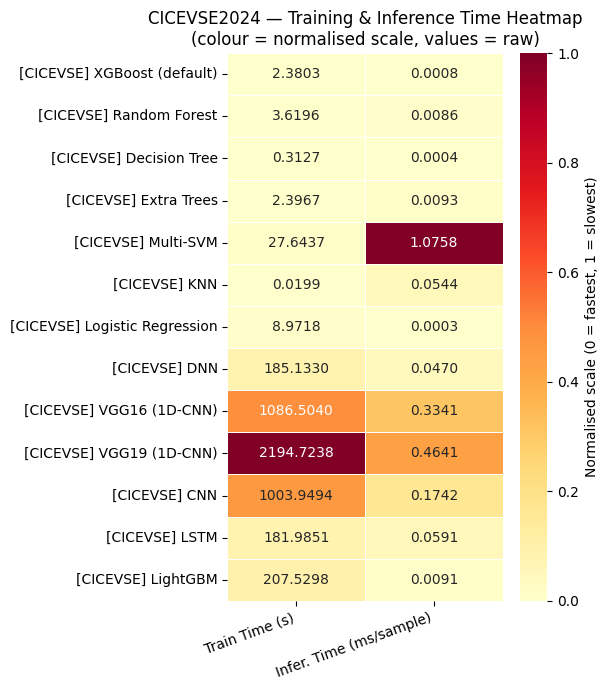

In [164]:
# Heatmap: Training time & Inference time
time_df = pd.DataFrame({
    "Train Time (s)":         [r.training_time_s   for r in results_cicevse],
    "Infer. Time (ms/sample)":[r.inference_time_ms for r in results_cicevse],
}, index=[r.model_name for r in results_cicevse])

# Min-max normalise each column for colour scale
norm_df = (time_df - time_df.min()) / (time_df.max() - time_df.min())

# Annotation strings showing raw values
annot = time_df.map(lambda v: f"{v:.4f}")

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    norm_df, annot=annot, fmt='', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Normalised scale (0 = fastest, 1 = slowest)'}
)
ax.set_title("CICEVSE2024 — Training & Inference Time Heatmap\n(colour = normalised scale, values = raw)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()

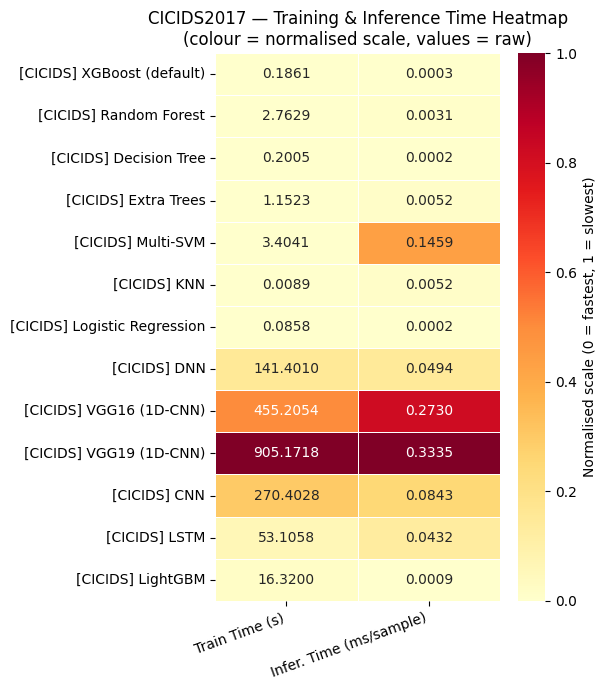

In [165]:
# Heatmap: Training time & Inference time (CICIDS2017)
time_df_cicids = pd.DataFrame({
    "Train Time (s)":         [r.training_time_s   for r in results_cicids],
    "Infer. Time (ms/sample)":[r.inference_time_ms for r in results_cicids],
}, index=[r.model_name for r in results_cicids])

# Min-max normalise each column for colour scale
norm_df = (time_df_cicids - time_df_cicids.min()) / (time_df_cicids.max() - time_df_cicids.min())

# Annotation strings showing raw values
annot = time_df_cicids.map(lambda v: f"{v:.4f}")

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    norm_df, annot=annot, fmt='', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Normalised scale (0 = fastest, 1 = slowest)'}
)
ax.set_title("CICIDS2017 — Training & Inference Time Heatmap\n(colour = normalised scale, values = raw)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()

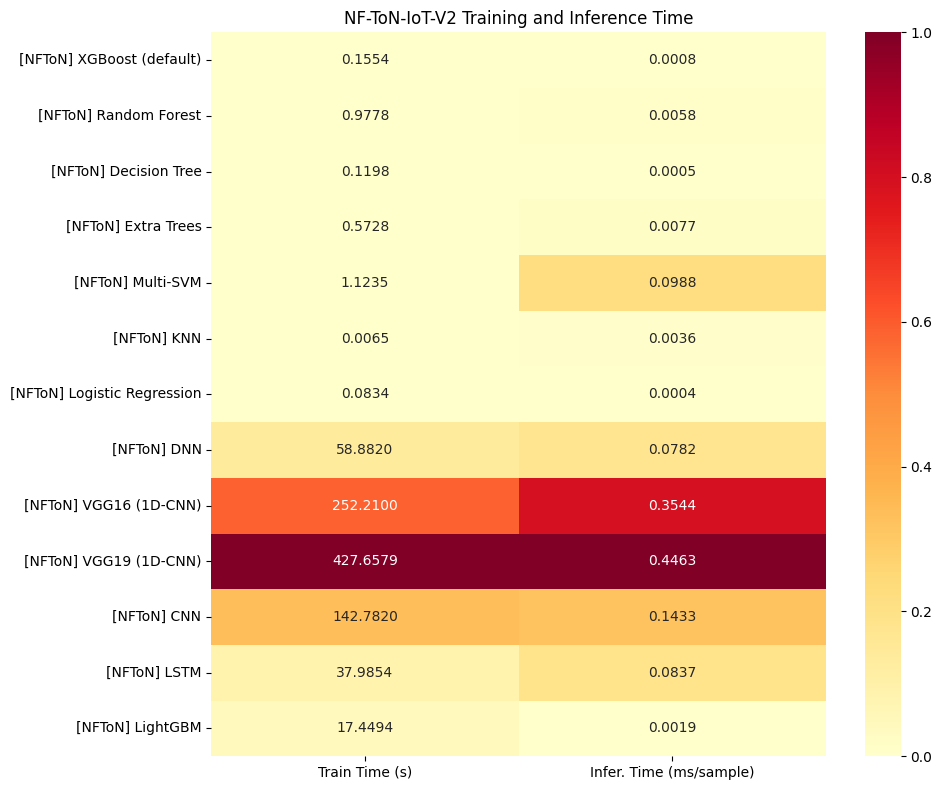

In [166]:
time_df_nfton = pd.DataFrame({
    "Train Time (s)": [r.training_time_s for r in results_nfton],
    "Infer. Time (ms/sample)": [r.inference_time_ms for r in results_nfton],
}, index=[r.model_name for r in results_nfton])

norm_df_nfton = (time_df_nfton - time_df_nfton.min()) / (time_df_nfton.max() - time_df_nfton.min())
annot_df_nfton = time_df_nfton.map(lambda v: f"{v:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(norm_df_nfton, annot=annot_df_nfton, fmt='', cmap='YlOrRd', cbar=True, ax=ax)
ax.set_title('NF-ToN-IoT-V2 Training and Inference Time')
plt.tight_layout()
plt.show()

# table for plotting and selection (all version)

In [167]:


def compute_macro_f1(result: ModelResult) -> float:
    f1_vals = []
    for cls_name, cls_metrics in result.per_class_metrics.items():
        if 'f1-score' in cls_metrics:
            f1_vals.append(cls_metrics['f1-score'])
        elif 'f1' in cls_metrics:
            f1_vals.append(cls_metrics['f1'])
    return float(np.mean(f1_vals)) if len(f1_vals) > 0 else np.nan


def infer_model_family(model_name: str) -> str:
    lower_name = model_name.lower()

    if any(x in lower_name for x in ['xgboost', 'random forest', 'decision tree', 'extra trees', 'lightgbm']):
        return 'Tree-Based'
    elif any(x in lower_name for x in ['svm', 'knn', 'logistic regression']):
        return 'Classical'
    elif any(x in lower_name for x in ['dnn', 'cnn', 'lstm', 'vgg']):
        return 'Deep Learning'
    else:
        return 'Other'


def build_plot_df(results_list, dataset_label: str):
    rows = []
    for r in results_list:
        rows.append({
            'Dataset': dataset_label,
            'Model': r.model_name,
            'Family': infer_model_family(r.model_name),
            'Accuracy (%)': r.accuracy * 100,
            'Weighted F1 (%)': r.f1_score * 100,
            'Macro F1 (%)': compute_macro_f1(r) * 100,
            'Precision (%)': r.precision * 100,
            'Recall (%)': r.recall * 100,
            'Accuracy Std (%)': r.accuracy_std * 100,
            'Weighted F1 Std (%)': r.f1_score_std * 100,
            'Train Time (s)': r.training_time_s,
            'Infer. Time (ms/sample)': r.inference_time_ms,
        })
    return pd.DataFrame(rows)


plot_df_cicevse = build_plot_df(results_cicevse, 'CICEVSE2024')
plot_df_cicids  = build_plot_df(results_cicids,  'CICIDS2017')
plot_df_nfton   = build_plot_df(results_nfton,   'NF-ToN-IoT-V2')

display(plot_df_cicevse)
display(plot_df_cicids)
display(plot_df_nfton)

,Dataset,Model,Family,Accuracy (%),Weighted F1 (%),Macro F1 (%),Precision (%),Recall (%),Accuracy Std (%),Weighted F1 Std (%),Train Time (s),Infer. Time (ms/sample)
0,CICEVSE2024,[CICEVSE] XGBoost (default),Tree-Based,99.894270,99.894673,99.179961,99.896327,99.894270,0.034306,0.034741,2.380306,0.000811
1,CICEVSE2024,[CICEVSE] Random Forest,Tree-Based,99.852535,99.853758,99.023237,99.857292,99.852535,0.055511,0.055529,3.619644,0.008642
2,CICEVSE2024,[CICEVSE] Decision Tree,Tree-Based,99.952700,99.952487,99.526049,99.952848,99.952700,0.019675,0.019523,0.312657,0.000356
3,CICEVSE2024,[CICEVSE] Extra Trees,Tree-Based,99.730112,99.730778,98.766215,99.732335,99.730112,0.075077,0.074453,2.396746,0.009280
4,CICEVSE2024,[CICEVSE] Multi-SVM,Classical,59.528118,50.494595,50.356881,60.801114,59.528118,0.060040,0.097817,27.643692,1.075785
5,CICEVSE2024,[CICEVSE] KNN,Classical,60.410114,59.475312,59.520365,59.424639,60.410114,0.221541,0.286211,0.019850,0.054445
6,CICEVSE2024,[CICEVSE] Logistic Regression,Classical,59.678366,53.482042,52.375880,60.391629,59.678366,0.186770,0.189607,8.971771,0.000270
7,CICEVSE2024,[CICEVSE] DNN,Deep Learning,55.365702,50.609901,53.787535,60.686361,55.365702,1.929897,0.827922,185.132961,0.047029
8,CICEVSE2024,[CICEVSE] VGG16 (1D-CNN),Deep Learning,60.348906,54.361198,55.637038,73.015780,60.348906,0.105483,0.105962,1086.503973,0.334051
9,CICEVSE2024,[CICEVSE] VGG19 (1D-CNN),Deep Learning,21.412871,7.552924,2.939402,4.585111,21.412871,0.004417,0.002841,2194.723757,0.464055


,Dataset,Model,Family,Accuracy (%),Weighted F1 (%),Macro F1 (%),Precision (%),Recall (%),Accuracy Std (%),Weighted F1 Std (%),Train Time (s),Infer. Time (ms/sample)
0,CICIDS2017,[CICIDS] XGBoost (default),Tree-Based,99.735011,99.734931,99.584626,99.734967,99.735011,0.029974,0.029984,0.186129,0.000299
1,CICIDS2017,[CICIDS] Random Forest,Tree-Based,99.674947,99.674706,99.490032,99.674660,99.674947,0.017999,0.018048,2.762930,0.003065
2,CICIDS2017,[CICIDS] Decision Tree,Tree-Based,99.505353,99.506007,99.227052,99.507667,99.505353,0.030393,0.029814,0.200480,0.000179
3,CICIDS2017,[CICIDS] Extra Trees,Tree-Based,99.537151,99.536790,99.273801,99.536729,99.537151,0.013241,0.013436,1.152298,0.005224
4,CICIDS2017,[CICIDS] Multi-SVM,Classical,92.937129,92.753548,88.370322,92.759195,92.937129,0.334642,0.328092,3.404136,0.145912
5,CICIDS2017,[CICIDS] KNN,Classical,98.533726,98.534948,97.706786,98.536466,98.533726,0.040851,0.040560,0.008893,0.005235
6,CICIDS2017,[CICIDS] Logistic Regression,Classical,88.821000,87.711099,79.347606,88.623247,88.821000,0.916097,1.303307,0.085780,0.000169
7,CICIDS2017,[CICIDS] DNN,Deep Learning,96.357274,96.377829,94.356586,96.415882,96.357274,0.224782,0.210054,141.401030,0.049390
8,CICIDS2017,[CICIDS] VGG16 (1D-CNN),Deep Learning,97.053304,97.091005,95.500461,97.190784,97.053304,0.246596,0.229856,455.205364,0.272998
9,CICIDS2017,[CICIDS] VGG19 (1D-CNN),Deep Learning,91.460060,88.525920,84.856823,86.206288,91.460060,8.054670,12.244920,905.171752,0.333509


,Dataset,Model,Family,Accuracy (%),Weighted F1 (%),Macro F1 (%),Precision (%),Recall (%),Accuracy Std (%),Weighted F1 Std (%),Train Time (s),Infer. Time (ms/sample)
0,NF-ToN-IoT-V2,[NFToN] XGBoost (default),Tree-Based,98.219987,98.214630,97.751152,98.216842,98.219987,0.163243,0.166099,0.155368,0.000818
1,NF-ToN-IoT-V2,[NFToN] Random Forest,Tree-Based,98.299980,98.293926,97.850238,98.297788,98.299980,0.222418,0.225895,0.977765,0.005806
2,NF-ToN-IoT-V2,[NFToN] Decision Tree,Tree-Based,97.600000,97.603481,96.993984,97.609534,97.600000,0.073493,0.073833,0.119804,0.000498
3,NF-ToN-IoT-V2,[NFToN] Extra Trees,Tree-Based,98.109982,98.102431,97.608032,98.108327,98.109982,0.213707,0.218137,0.572849,0.007685
4,NF-ToN-IoT-V2,[NFToN] Multi-SVM,Classical,90.160012,89.922483,87.067589,90.024378,90.160012,0.128710,0.125726,1.123460,0.098778
5,NF-ToN-IoT-V2,[NFToN] KNN,Classical,94.109978,93.973061,92.273827,94.174491,94.109978,0.163876,0.199302,0.006465,0.003554
6,NF-ToN-IoT-V2,[NFToN] Logistic Regression,Classical,72.990007,64.981431,49.360148,68.583811,72.990007,0.133360,0.231863,0.083397,0.000437
7,NF-ToN-IoT-V2,[NFToN] DNN,Deep Learning,95.550179,95.580861,94.460404,95.724262,95.550179,1.313892,1.255200,58.881965,0.078199
8,NF-ToN-IoT-V2,[NFToN] VGG16 (1D-CNN),Deep Learning,95.180076,95.073325,93.684656,95.278458,95.180076,0.556430,0.560876,252.209979,0.354426
9,NF-ToN-IoT-V2,[NFToN] VGG19 (1D-CNN),Deep Learning,80.318452,72.602543,66.314807,67.077155,80.318452,10.947702,16.345343,427.657912,0.446272


## training time vs weighted F1

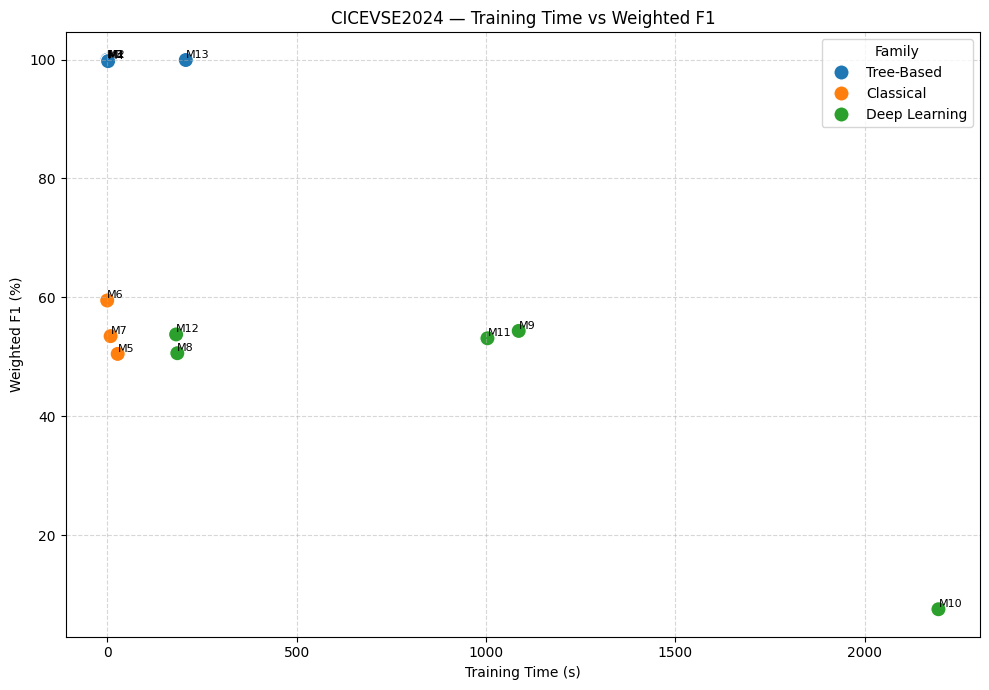

,Point ID,Model,Family,Train Time (s),Weighted F1 (%)
2,M3,[CICEVSE] Decision Tree,Tree-Based,0.312657,99.952487
12,M13,[CICEVSE] LightGBM,Tree-Based,207.529849,99.919660
0,M1,[CICEVSE] XGBoost (default),Tree-Based,2.380306,99.894673
1,M2,[CICEVSE] Random Forest,Tree-Based,3.619644,99.853758
3,M4,[CICEVSE] Extra Trees,Tree-Based,2.396746,99.730778
5,M6,[CICEVSE] KNN,Classical,0.019850,59.475312
8,M9,[CICEVSE] VGG16 (1D-CNN),Deep Learning,1086.503973,54.361198
11,M12,[CICEVSE] LSTM,Deep Learning,181.985130,53.771403
6,M7,[CICEVSE] Logistic Regression,Classical,8.971771,53.482042
10,M11,[CICEVSE] CNN,Deep Learning,1003.949361,53.121309


In [168]:
plot_df_temp = plot_df_cicevse.copy().reset_index(drop=True)
plot_df_temp['Point ID'] = [f'M{i+1}' for i in range(len(plot_df_temp))]

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=plot_df_temp,
    x='Train Time (s)',
    y='Weighted F1 (%)',
    hue='Family',
    s=120,
    ax=ax
)

for _, row in plot_df_temp.iterrows():
    ax.text(
        row['Train Time (s)'],
        row['Weighted F1 (%)'],
        row['Point ID'],
        fontsize=8,
        ha='left',
        va='bottom'
    )

ax.set_xlabel('Training Time (s)')
ax.set_ylabel('Weighted F1 (%)')
ax.set_title('CICEVSE2024 — Training Time vs Weighted F1')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

display(plot_df_temp[['Point ID', 'Model', 'Family', 'Train Time (s)', 'Weighted F1 (%)']].sort_values('Weighted F1 (%)', ascending=False))

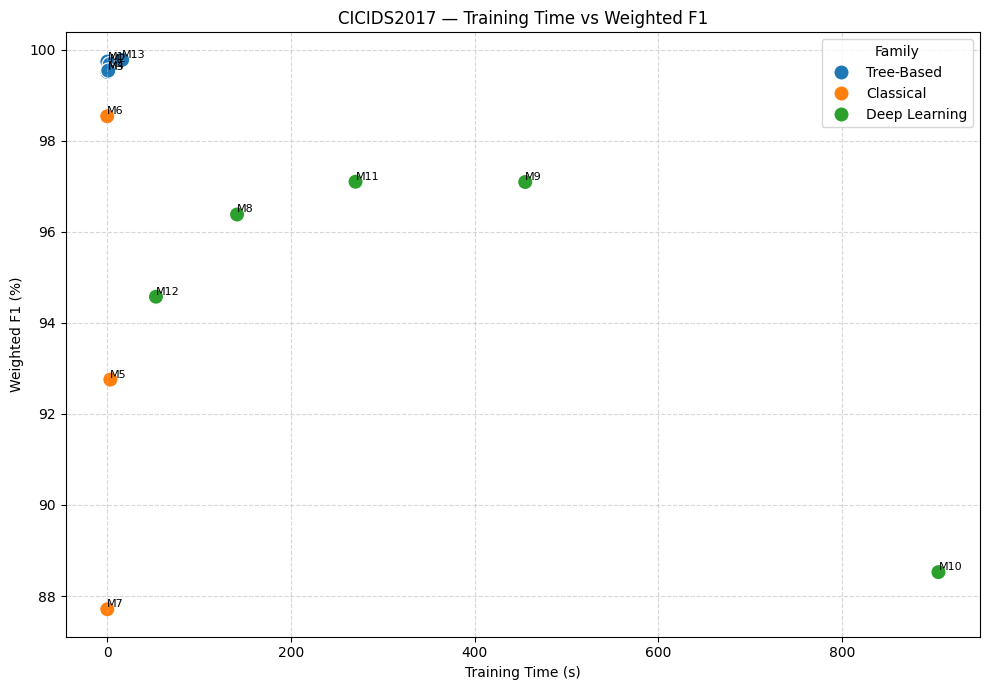

,Point ID,Model,Family,Train Time (s),Weighted F1 (%)
12,M13,[CICIDS] LightGBM,Tree-Based,16.319995,99.773774
0,M1,[CICIDS] XGBoost (default),Tree-Based,0.186129,99.734931
1,M2,[CICIDS] Random Forest,Tree-Based,2.762930,99.674706
3,M4,[CICIDS] Extra Trees,Tree-Based,1.152298,99.536790
2,M3,[CICIDS] Decision Tree,Tree-Based,0.200480,99.506007
5,M6,[CICIDS] KNN,Classical,0.008893,98.534948
10,M11,[CICIDS] CNN,Deep Learning,270.402760,97.097894
8,M9,[CICIDS] VGG16 (1D-CNN),Deep Learning,455.205364,97.091005
7,M8,[CICIDS] DNN,Deep Learning,141.401030,96.377829
11,M12,[CICIDS] LSTM,Deep Learning,53.105812,94.572977


In [169]:
plot_df_temp = plot_df_cicids.copy().reset_index(drop=True)
plot_df_temp['Point ID'] = [f'M{i+1}' for i in range(len(plot_df_temp))]

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=plot_df_temp,
    x='Train Time (s)',
    y='Weighted F1 (%)',
    hue='Family',
    s=120,
    ax=ax
)

for _, row in plot_df_temp.iterrows():
    ax.text(
        row['Train Time (s)'],
        row['Weighted F1 (%)'],
        row['Point ID'],
        fontsize=8,
        ha='left',
        va='bottom'
    )

ax.set_xlabel('Training Time (s)')
ax.set_ylabel('Weighted F1 (%)')
ax.set_title('CICIDS2017 — Training Time vs Weighted F1')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

display(plot_df_temp[['Point ID', 'Model', 'Family', 'Train Time (s)', 'Weighted F1 (%)']].sort_values('Weighted F1 (%)', ascending=False))

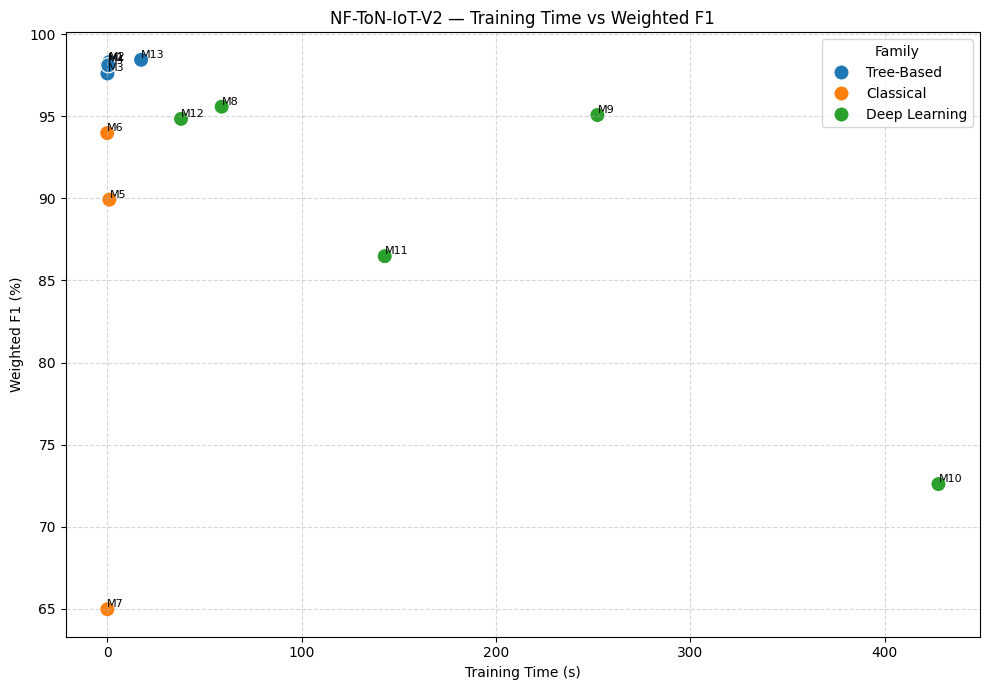

,Point ID,Model,Family,Train Time (s),Weighted F1 (%)
12,M13,[NFToN] LightGBM,Tree-Based,17.449352,98.435422
1,M2,[NFToN] Random Forest,Tree-Based,0.977765,98.293926
0,M1,[NFToN] XGBoost (default),Tree-Based,0.155368,98.214630
3,M4,[NFToN] Extra Trees,Tree-Based,0.572849,98.102431
2,M3,[NFToN] Decision Tree,Tree-Based,0.119804,97.603481
7,M8,[NFToN] DNN,Deep Learning,58.881965,95.580861
8,M9,[NFToN] VGG16 (1D-CNN),Deep Learning,252.209979,95.073325
11,M12,[NFToN] LSTM,Deep Learning,37.985393,94.839724
5,M6,[NFToN] KNN,Classical,0.006465,93.973061
4,M5,[NFToN] Multi-SVM,Classical,1.123460,89.922483


In [170]:
plot_df_temp = plot_df_nfton.copy().reset_index(drop=True)
plot_df_temp['Point ID'] = [f'M{i+1}' for i in range(len(plot_df_temp))]

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=plot_df_temp,
    x='Train Time (s)',
    y='Weighted F1 (%)',
    hue='Family',
    s=120,
    ax=ax
)

for _, row in plot_df_temp.iterrows():
    ax.text(
        row['Train Time (s)'],
        row['Weighted F1 (%)'],
        row['Point ID'],
        fontsize=8,
        ha='left',
        va='bottom'
    )

ax.set_xlabel('Training Time (s)')
ax.set_ylabel('Weighted F1 (%)')
ax.set_title('NF-ToN-IoT-V2 — Training Time vs Weighted F1')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

display(plot_df_temp[['Point ID', 'Model', 'Family', 'Train Time (s)', 'Weighted F1 (%)']].sort_values('Weighted F1 (%)', ascending=False))

## Weighted F1 vs Macro F1


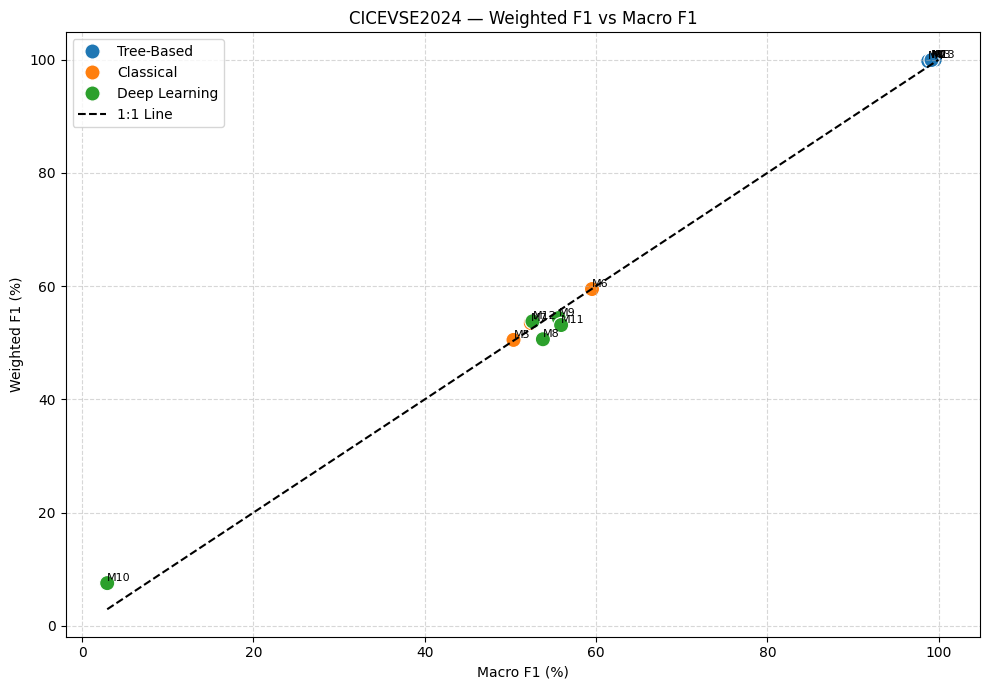

,Point ID,Model,Family,Macro F1 (%),Weighted F1 (%)
2,M3,[CICEVSE] Decision Tree,Tree-Based,99.526049,99.952487
12,M13,[CICEVSE] LightGBM,Tree-Based,99.145477,99.919660
0,M1,[CICEVSE] XGBoost (default),Tree-Based,99.179961,99.894673
1,M2,[CICEVSE] Random Forest,Tree-Based,99.023237,99.853758
3,M4,[CICEVSE] Extra Trees,Tree-Based,98.766215,99.730778
5,M6,[CICEVSE] KNN,Classical,59.520365,59.475312
8,M9,[CICEVSE] VGG16 (1D-CNN),Deep Learning,55.637038,54.361198
11,M12,[CICEVSE] LSTM,Deep Learning,52.574749,53.771403
6,M7,[CICEVSE] Logistic Regression,Classical,52.375880,53.482042
10,M11,[CICEVSE] CNN,Deep Learning,55.916086,53.121309


In [171]:
plot_df_temp = plot_df_cicevse.copy().reset_index(drop=True)
plot_df_temp['Point ID'] = [f'M{i+1}' for i in range(len(plot_df_temp))]

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=plot_df_temp,
    x='Macro F1 (%)',
    y='Weighted F1 (%)',
    hue='Family',
    s=120,
    ax=ax
)

for _, row in plot_df_temp.iterrows():
    ax.text(
        row['Macro F1 (%)'],
        row['Weighted F1 (%)'],
        row['Point ID'],
        fontsize=8,
        ha='left',
        va='bottom'
    )

min_val = min(plot_df_temp['Macro F1 (%)'].min(), plot_df_temp['Weighted F1 (%)'].min())
max_val = max(plot_df_temp['Macro F1 (%)'].max(), plot_df_temp['Weighted F1 (%)'].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1.5, color='black', label='1:1 Line')

ax.set_xlabel('Macro F1 (%)')
ax.set_ylabel('Weighted F1 (%)')
ax.set_title('CICEVSE2024 — Weighted F1 vs Macro F1')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

display(plot_df_temp[['Point ID', 'Model', 'Family', 'Macro F1 (%)', 'Weighted F1 (%)']].sort_values('Weighted F1 (%)', ascending=False))

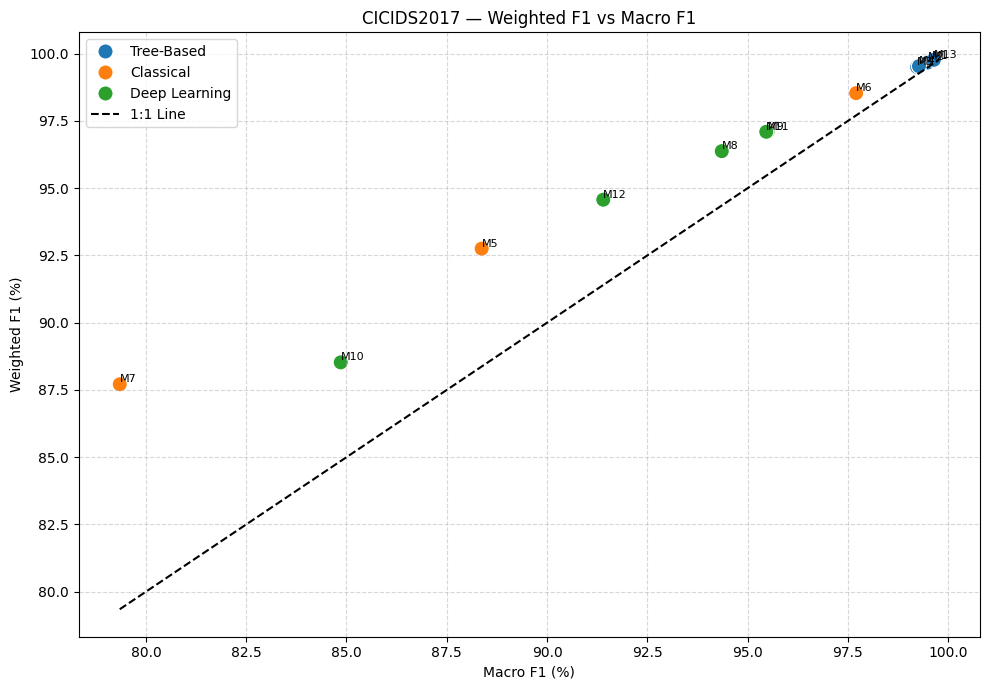

,Point ID,Model,Family,Macro F1 (%),Weighted F1 (%)
12,M13,[CICIDS] LightGBM,Tree-Based,99.645476,99.773774
0,M1,[CICIDS] XGBoost (default),Tree-Based,99.584626,99.734931
1,M2,[CICIDS] Random Forest,Tree-Based,99.490032,99.674706
3,M4,[CICIDS] Extra Trees,Tree-Based,99.273801,99.536790
2,M3,[CICIDS] Decision Tree,Tree-Based,99.227052,99.506007
5,M6,[CICIDS] KNN,Classical,97.706786,98.534948
10,M11,[CICIDS] CNN,Deep Learning,95.466724,97.097894
8,M9,[CICIDS] VGG16 (1D-CNN),Deep Learning,95.500461,97.091005
7,M8,[CICIDS] DNN,Deep Learning,94.356586,96.377829
11,M12,[CICIDS] LSTM,Deep Learning,91.402760,94.572977


In [172]:
plot_df_temp = plot_df_cicids.copy().reset_index(drop=True)
plot_df_temp['Point ID'] = [f'M{i+1}' for i in range(len(plot_df_temp))]

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=plot_df_temp,
    x='Macro F1 (%)',
    y='Weighted F1 (%)',
    hue='Family',
    s=120,
    ax=ax
)

for _, row in plot_df_temp.iterrows():
    ax.text(
        row['Macro F1 (%)'],
        row['Weighted F1 (%)'],
        row['Point ID'],
        fontsize=8,
        ha='left',
        va='bottom'
    )

min_val = min(plot_df_temp['Macro F1 (%)'].min(), plot_df_temp['Weighted F1 (%)'].min())
max_val = max(plot_df_temp['Macro F1 (%)'].max(), plot_df_temp['Weighted F1 (%)'].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1.5, color='black', label='1:1 Line')

ax.set_xlabel('Macro F1 (%)')
ax.set_ylabel('Weighted F1 (%)')
ax.set_title('CICIDS2017 — Weighted F1 vs Macro F1')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

display(plot_df_temp[['Point ID', 'Model', 'Family', 'Macro F1 (%)', 'Weighted F1 (%)']].sort_values('Weighted F1 (%)', ascending=False))

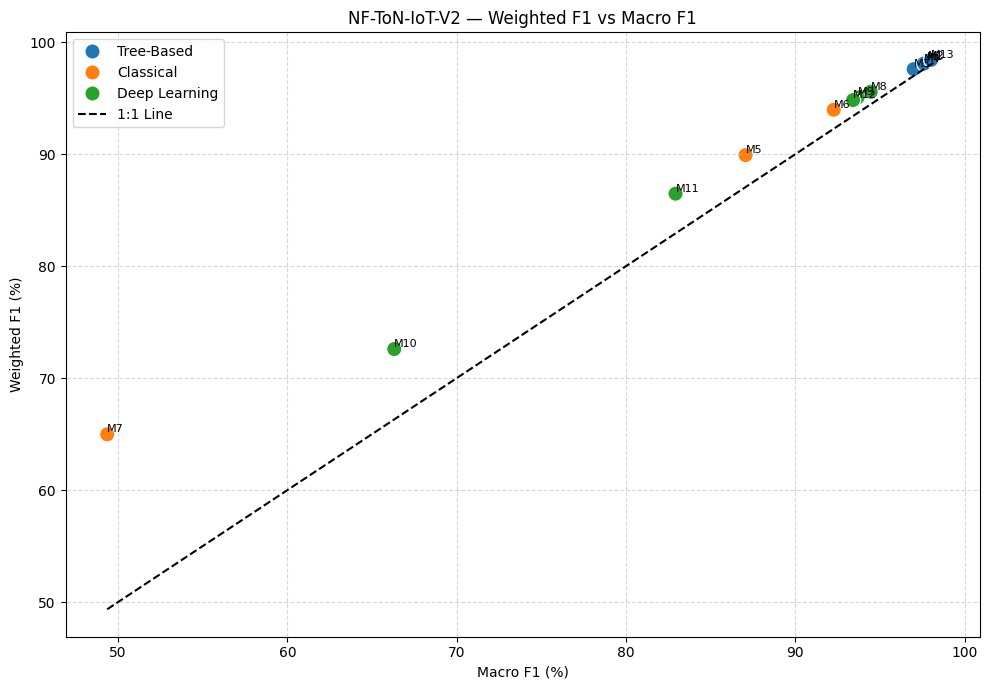

,Point ID,Model,Family,Macro F1 (%),Weighted F1 (%)
12,M13,[NFToN] LightGBM,Tree-Based,98.029554,98.435422
1,M2,[NFToN] Random Forest,Tree-Based,97.850238,98.293926
0,M1,[NFToN] XGBoost (default),Tree-Based,97.751152,98.214630
3,M4,[NFToN] Extra Trees,Tree-Based,97.608032,98.102431
2,M3,[NFToN] Decision Tree,Tree-Based,96.993984,97.603481
7,M8,[NFToN] DNN,Deep Learning,94.460404,95.580861
8,M9,[NFToN] VGG16 (1D-CNN),Deep Learning,93.684656,95.073325
11,M12,[NFToN] LSTM,Deep Learning,93.417192,94.839724
5,M6,[NFToN] KNN,Classical,92.273827,93.973061
4,M5,[NFToN] Multi-SVM,Classical,87.067589,89.922483


In [173]:
plot_df_temp = plot_df_nfton.copy().reset_index(drop=True)
plot_df_temp['Point ID'] = [f'M{i+1}' for i in range(len(plot_df_temp))]

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=plot_df_temp,
    x='Macro F1 (%)',
    y='Weighted F1 (%)',
    hue='Family',
    s=120,
    ax=ax
)

for _, row in plot_df_temp.iterrows():
    ax.text(
        row['Macro F1 (%)'],
        row['Weighted F1 (%)'],
        row['Point ID'],
        fontsize=8,
        ha='left',
        va='bottom'
    )

min_val = min(plot_df_temp['Macro F1 (%)'].min(), plot_df_temp['Weighted F1 (%)'].min())
max_val = max(plot_df_temp['Macro F1 (%)'].max(), plot_df_temp['Weighted F1 (%)'].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1.5, color='black', label='1:1 Line')

ax.set_xlabel('Macro F1 (%)')
ax.set_ylabel('Weighted F1 (%)')
ax.set_title('NF-ToN-IoT-V2 — Weighted F1 vs Macro F1')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

display(plot_df_temp[['Point ID', 'Model', 'Family', 'Macro F1 (%)', 'Weighted F1 (%)']].sort_values('Weighted F1 (%)', ascending=False))

## overall computation cost proxy vs weighted F1 (not finished !)

In [174]:
def add_overall_cost_proxy(plot_df):
    temp_df = plot_df.copy()

    train_norm = (temp_df['Train Time (s)'] - temp_df['Train Time (s)'].min()) / (
        temp_df['Train Time (s)'].max() - temp_df['Train Time (s)'].min()
    )

    infer_norm = (temp_df['Infer. Time (ms/sample)'] - temp_df['Infer. Time (ms/sample)'].min()) / (
        temp_df['Infer. Time (ms/sample)'].max() - temp_df['Infer. Time (ms/sample)'].min()
    )

    temp_df['Overall Cost Proxy'] = (train_norm + infer_norm) / 2

    # Not finished due absence of true  memory footprint and on-device power usage
    # similar to the heatmap but more accurate if we need it1
    return temp_df


plot_df_cicevse_cost = add_overall_cost_proxy(plot_df_cicevse)
plot_df_cicids_cost  = add_overall_cost_proxy(plot_df_cicids)
plot_df_nfton_cost   = add_overall_cost_proxy(plot_df_nfton)

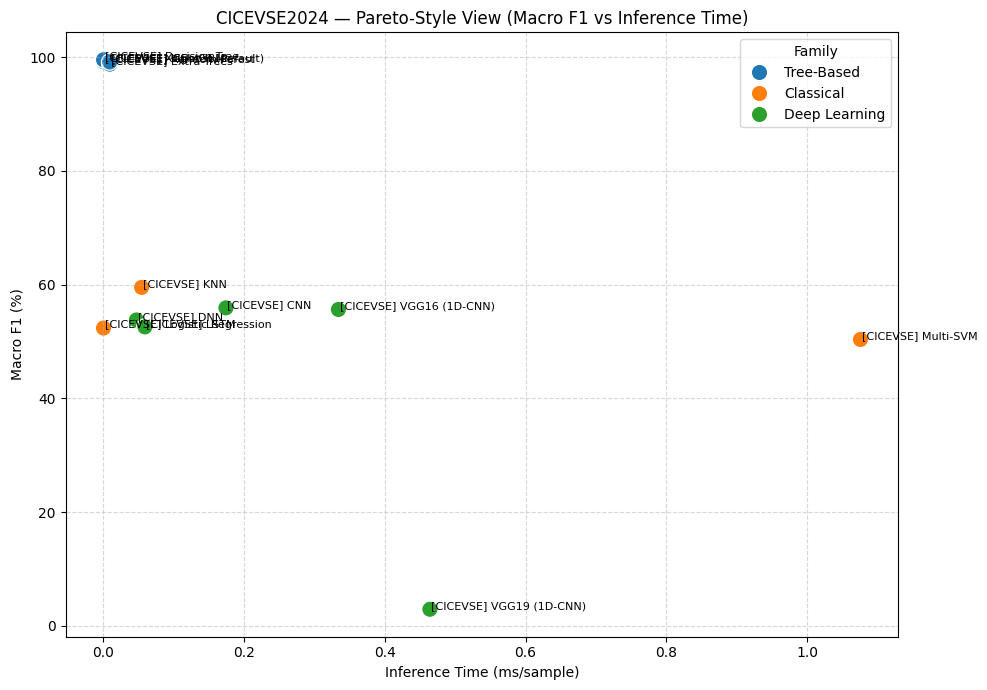

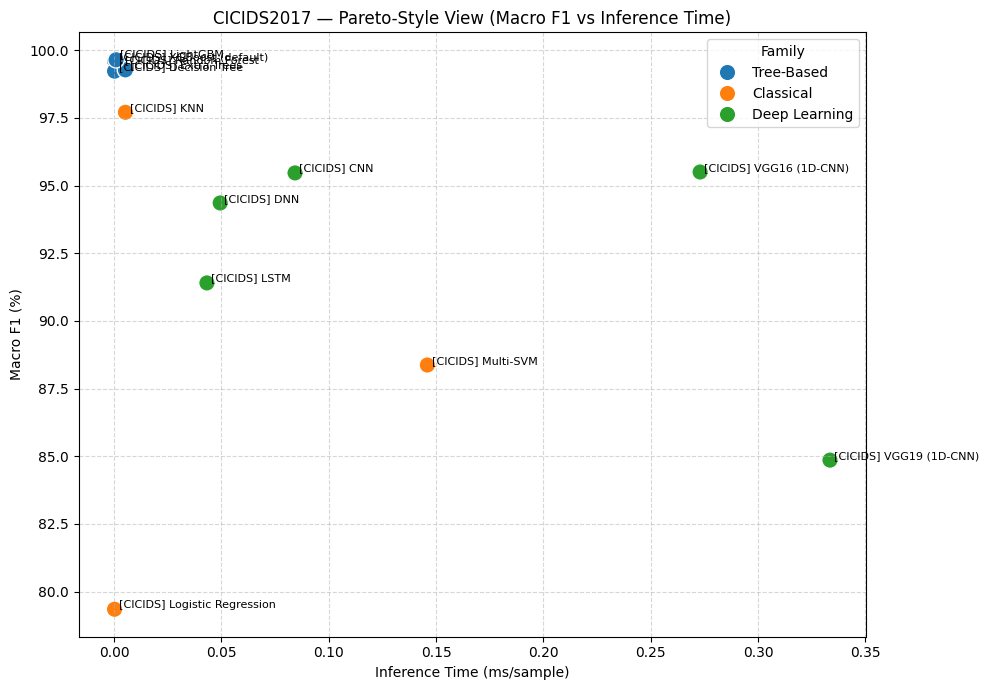

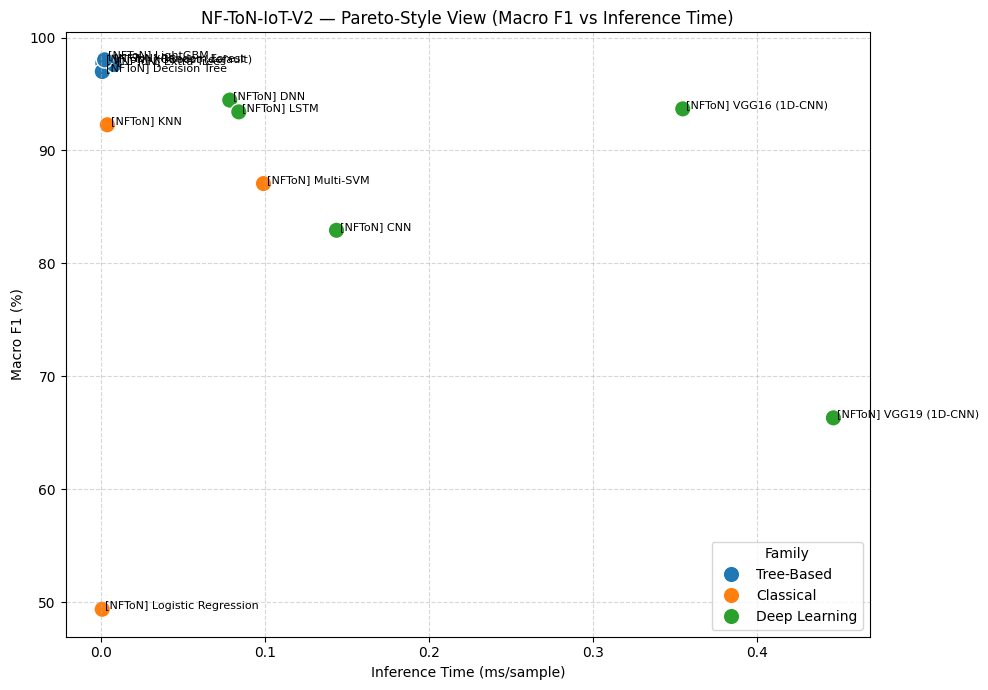

In [175]:
def plot_pareto_style(plot_df, dataset_title: str):
    fig, ax = plt.subplots(figsize=(10, 7))

    sns.scatterplot(
        data=plot_df,
        x='Infer. Time (ms/sample)',
        y='Macro F1 (%)',
        hue='Family',
        s=140,
        ax=ax
    )

    for _, row in plot_df.iterrows():
        ax.text(
            row['Infer. Time (ms/sample)'] + 0.002,
            row['Macro F1 (%)'] + 0.05,
            row['Model'],
            fontsize=8
        )

    ax.set_xlabel('Inference Time (ms/sample)')
    ax.set_ylabel('Macro F1 (%)')
    ax.set_title(f'{dataset_title} — Pareto-Style View (Macro F1 vs Inference Time)')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_pareto_style(plot_df_cicevse, 'CICEVSE2024')
plot_pareto_style(plot_df_cicids,  'CICIDS2017')
plot_pareto_style(plot_df_nfton,   'NF-ToN-IoT-V2')

## best candidate from each family
# LightGBM results not accurate due to the current run does not include dedicated hyperparameter tuning.


In [176]:
def get_best_by_family(plot_df):
    family_best_rows = []

    for family_name in plot_df['Family'].unique():
        sub_df = plot_df[plot_df['Family'] == family_name].copy()

        sub_df = sub_df.sort_values(
            ['Weighted F1 (%)', 'Macro F1 (%)', 'Infer. Time (ms/sample)'],
            ascending=[False, False, True]
        )

        family_best_rows.append(sub_df.iloc[0])

    return pd.DataFrame(family_best_rows).reset_index(drop=True)


best_family_cicevse = get_best_by_family(plot_df_cicevse_cost)
best_family_cicids  = get_best_by_family(plot_df_cicids_cost)
best_family_nfton   = get_best_by_family(plot_df_nfton_cost)

display(best_family_cicevse)
display(best_family_cicids)
display(best_family_nfton)

,Dataset,Model,Family,Accuracy (%),Weighted F1 (%),Macro F1 (%),Precision (%),Recall (%),Accuracy Std (%),Weighted F1 Std (%),Train Time (s),Infer. Time (ms/sample),Overall Cost Proxy
0,CICEVSE2024,[CICEVSE] Decision Tree,Tree-Based,99.952700,99.952487,99.526049,99.952848,99.952700,0.019675,0.019523,0.312657,0.000356,0.000107
1,CICEVSE2024,[CICEVSE] KNN,Classical,60.410114,59.475312,59.520365,59.424639,60.410114,0.221541,0.286211,0.019850,0.054445,0.025186
2,CICEVSE2024,[CICEVSE] VGG16 (1D-CNN),Deep Learning,60.348906,54.361198,55.637038,73.015780,60.348906,0.105483,0.105962,1086.503973,0.334051,0.402697


,Dataset,Model,Family,Accuracy (%),Weighted F1 (%),Macro F1 (%),Precision (%),Recall (%),Accuracy Std (%),Weighted F1 Std (%),Train Time (s),Infer. Time (ms/sample),Overall Cost Proxy
0,CICIDS2017,[CICIDS] LightGBM,Tree-Based,99.773875,99.773774,99.645476,99.773787,99.773875,0.027825,0.027928,16.319995,0.000890,0.010091
1,CICIDS2017,[CICIDS] KNN,Classical,98.533726,98.534948,97.706786,98.536466,98.533726,0.040851,0.040560,0.008893,0.005235,0.007598
2,CICIDS2017,[CICIDS] CNN,Deep Learning,97.102802,97.097894,95.466724,97.148140,97.102802,0.472648,0.506397,270.402760,0.084263,0.275500


,Dataset,Model,Family,Accuracy (%),Weighted F1 (%),Macro F1 (%),Precision (%),Recall (%),Accuracy Std (%),Weighted F1 Std (%),Train Time (s),Infer. Time (ms/sample),Overall Cost Proxy
0,NF-ToN-IoT-V2,[NFToN] LightGBM,Tree-Based,98.439991,98.435422,98.029554,98.437570,98.439991,0.241326,0.243748,17.449352,0.001906,0.022041
1,NF-ToN-IoT-V2,[NFToN] KNN,Classical,94.109978,93.973061,92.273827,94.174491,94.109978,0.163876,0.199302,0.006465,0.003554,0.003496
2,NF-ToN-IoT-V2,[NFToN] DNN,Deep Learning,95.550179,95.580861,94.460404,95.724262,95.550179,1.313892,1.255200,58.881965,0.078199,0.156045
